# Step 3 analysis — 37 base-world runs

This notebook characterizes the 37 base-world run outputs from NREL: the 25
Step 3 production runs plus the 12 `large100_{sched}_{p05,p95}` percentile
runs that returned with the Step 4 delivery (2026-08-15).
The Step 3 files are in `D:\ReEDS files\nuclear-learning\smr100 first run`;
the large100 percentile files are in `D:\ReEDS files\nuclear-learning\step4 runs`.
The run matrices are `cases_nuclearlearning_smr100.csv`
(18 smr100 cases + 6 large100 p50 cases + 1 equality case) and the 12
large100 percentile columns of `cases_nuclearlearning_step4.csv`.
The QA notebooks (`z-ethan/step3_checks/`, 44 pass/fail tests, and
`z-ethan/step4_checks/`, 44 pass/fail tests) already passed on these files. This notebook does the analysis that
follows: the mandate duals, the system costs, the system NPV, and the years in
which the mandates do not bind.

Sections:

- S1 — run inventory and mandate schedules.
- S2 — where the mandates bind, and where they do not (adverse findings first).
- S3 — dual price trajectories (the headline object).
- S4 — dual price against schedule ambition (cross-section).
- S5 — bridge shape: dual decay metrics.
- S6 — system costs.
- S7 — system NPV.
- S8 — rental transfer, ITC translation, and fiscal outputs.
- S9 — equality-flip note.
- S10 — caveats and output manifest.

**Units.** The h5 files hold dollars of 2004. This notebook shows dollars of
2024 in all figures and tables. Dual prices show as $/kW-yr. Costs show as
billion $ per year. NPV shows as billion $.

**Two standing rules.**

1. Each schedule x percentile case is its own joint cost-world draw. The clean
   comparison axes are: (a) dual trajectories, (b) percentile fans inside one
   schedule, and (c) smr100 against large100 percentile bands as conditional what-ifs.
   Comparisons across schedules mix the mandate and the drawn cost world. They
   are descriptive, not causal.
2. Adverse results get equal prominence. The notebook reports slack mandates,
   zero duals, and large subsidies as visibly as the favorable results. The
   notebook does not rank the trajectories by desirability.

Run this notebook on the **playground-env** kernel, from `z-ethan/step3_analysis/`.
This notebook only reads the files on drive D. It does not change them.

In [1]:
import json
from pathlib import Path

import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)

HERE = Path.cwd()
assert HERE.name == "step3_analysis", f"run from z-ethan/step3_analysis/, not {HERE}"
REPO = HERE.parents[1]
EXPORTS = HERE / "exports"
FIGURES = HERE / "figures"
EXPORTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
CHECKS_EXPORTS = REPO / "z-ethan" / "step3_checks" / "exports"

# all run outputs consolidated into one flat folder (drive reorganized 2026-08-18)
H5_DIR = Path("D:/ReEDS files/nuclear-learning/All runs so far")
H5_DIR4 = H5_DIR                                # large100 p05/p95 (Step 4 delivery)

# ---- case matrix ----------------------------------------------------------------
cases_csv = pd.read_csv(REPO / "cases_nuclearlearning_smr100.csv", index_col=0)
CASES = [c for c in cases_csv.columns if c != "Default Value"]
assert len(CASES) == 25, CASES

# Step 4 delivery (2026-08-15): the 12 large100 percentile cases complete the
# traditional-nuclear arm to p05/p50/p95. They are base-world runs and belong
# in this notebook; the 108 market-sensitivity runs live in z-ethan/step4_analysis.
cases_csv4 = pd.read_csv(REPO / "cases_nuclearlearning_step4.csv", index_col=0)
CASES4_LARGE = [c for c in cases_csv4.columns if c.startswith("large100_")]
assert len(CASES4_LARGE) == 12, CASES4_LARGE
CASES = CASES + CASES4_LARGE
assert len(CASES) == 37, len(CASES)

def sw(case, name):
    """Read one switch value for one case. An empty cell uses the default value."""
    csv_ = cases_csv4 if case in CASES4_LARGE else cases_csv
    v = csv_.loc[name, case]
    if pd.isna(v) or str(v).strip() == "":
        v = csv_.loc[name, "Default Value"]
    return str(v).strip()

META = {}
for c in CASES:
    ts = sw(c, "GSw_NuclearCapMandateTechScen")
    META[c] = dict(
        scen=sw(c, "GSw_NuclearCapMandateScen"),
        mode=int(float(sw(c, "GSw_NuclearCapMandate"))),
        techscen=ts,
        mandated_tech={"smr": "nuclear-smr", "large": "nuclear"}[ts],
    )
SMR_CASES = [c for c in CASES if META[c]["techscen"] == "smr"]
LARGE_CASES = [c for c in CASES if META[c]["techscen"] == "large"]
SCHEDULES = ["eia", "aj", "iaea", "mck", "cop28", "eo"]      # ordered by 2050 ambition
SCHED_GW = {"eia": 117.3, "aj": 134.0, "iaea": 172.3, "mck": 200.0,
            "cop28": 300.0, "eo": 400.0}                     # 2050 schedule ambition, GW
SCHED_LABEL = {"eia": "EIA AEO high (117 GW)", "aj": "Abou-Jaoude (134 GW)",
               "iaea": "IAEA high (172 GW)", "mck": "McKinsey (200 GW)",
               "cop28": "COP28 (300 GW)", "eo": "EO 2025 (400 GW)"}
REF = "smr100_eia_p50"     # reference case for single-case exhibits

def parse_case(c):
    """Split a case name into (family, schedule, percentile, variant)."""
    fam = "large" if c.startswith("large100") else "smr"
    parts = c.split("_")
    return fam, parts[1], parts[2], ("eq" if c.endswith("_eq") else "")

H5 = {c: (H5_DIR4 / f"step4_{c}_outputs.h5" if c in CASES4_LARGE
          else H5_DIR / f"test1_{c}_outputs.h5") for c in CASES}
missing = [c for c in CASES if not H5[c].exists()]
assert not missing, f"missing h5 files: {missing}"

# 2022$ -> 2004$ (ReEDS-internal dollars). deflator.csv: Deflator(t) relative to 2004.
DEFL = pd.read_csv(REPO / "inputs" / "financials" / "deflator.csv")
DEFL.columns = ["t", "Deflator"]
DEFL = DEFL.set_index("t")["Deflator"]
D2022 = float(DEFL.loc[2022])
TO2024 = 1.0 / float(DEFL.loc[2024])

# ---- self-contained outputs.h5 reader (no `reeds` import: env/DLL constraints) --
_CACHE = {}

def load(case, key):
    """Read one report parameter from an outputs.h5 file as a DataFrame.
    Layout per reeds/io.py::write_output_to_h5: one group per parameter, a `columns`
    dataset for order, one dataset per column (byte strings) + float `Value`.
    Do not change the returned frame in place: it is cached."""
    if (case, key) in _CACHE:
        return _CACHE[(case, key)]
    with h5py.File(H5[case], "r") as f:
        if key not in f:
            raise KeyError(f"{key} not in {H5[case].name}")
        g = f[key]
        cols = [c.decode() for c in g["columns"][:]]
        data = {}
        for c in cols:
            arr = g[c][:]
            data[c] = arr.astype(str) if arr.dtype.kind == "S" else arr
        df = pd.DataFrame(data)[cols]
    for c in ("t", "allt"):
        if c in df.columns:
            df[c] = df[c].astype(int)
    _CACHE[(case, key)] = df
    return df

def h5_keys(case):
    with h5py.File(H5[case], "r") as f:
        return sorted(f.keys())

print(f"repo: {REPO}")
print(f"cases: {len(CASES)} ({len(SMR_CASES)} smr100 + {len(LARGE_CASES)} large100, "
      f"incl. equality copy)")
print(f"2022$->2004$ deflator: {D2022:.6f}; 2004$->2024$: {TO2024:.4f}")


repo: C:\Users\ethan\code\research\ReEDS-nuclear-learning
cases: 37 (19 smr100 + 18 large100, incl. equality copy)
2022$->2004$ deflator: 0.645694; 2004$->2024$: 1.6590


In [2]:
# ---- house figure style: z-ethan/plotstyle.py is the normative standard ----------
import sys
sys.path.insert(0, str(HERE.parent))
import plotstyle as ps
ps.apply()
COL = ps.COL
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT,
                                              ps.GRID_C, ps.EDGE_C, ps.SURFACE)

# Schedule identity and percentile weight come from the central palette
# (identical hexes and values; the ramp is now hardcoded in plotstyle).
assert SCHEDULES == ps.SCHED_ORDER, (SCHEDULES, ps.SCHED_ORDER)
SCHED_C = dict(ps.SCHED_C)
PCT_STYLE = dict(ps.PCT_STYLE)

def savefig(fig, name):
    p = FIGURES / name
    ps.savefig(fig, p)
    return p

print("schedule colors:", SCHED_C)


schedule colors: {'eia': '#46085c', 'aj': '#453781', 'iaea': '#355f8d', 'mck': '#26828e', 'cop28': '#20a386', 'eo': '#4ec36b'}


In [3]:
# ---- real discount rate (same derivation as step3_checks B5) ----------------------
FIN_DIR = REPO / "inputs" / "financials"
YEARS = np.arange(2010, 2051)

sys_fin = pd.read_csv(FIN_DIR / "financials_sys_ATB2024.csv")
infl = pd.read_csv(FIN_DIR / "inflation_default.csv")
sys_fin = sys_fin.merge(infl, on="t", how="left")
sys_fin["d_nom"] = ((1 - sys_fin["debt_fraction"]) * (sys_fin["rroe_nom"] - 1)
                    + sys_fin["debt_fraction"] * (sys_fin["interest_rate_nom"] - 1)
                      * (1 - sys_fin["tax_rate"]) + 1)
sys_fin["d_real"] = sys_fin["d_nom"] / sys_fin["inflation_rate"]

def on_years(col):
    s = sys_fin.set_index("t")[col].reindex(range(1990, YEARS[-1] + 1)).ffill()
    return s.loc[YEARS].to_numpy(float)

D_REAL = on_years("d_real")
D_NOM = on_years("d_nom")
TAX = on_years("tax_rate")
IB = on_years("interest_rate_nom")
DR = float(np.mean(D_REAL))     # scalar real rate for the PV formulas (choice on record)

def yi(t):
    return int(t - YEARS[0])

print(f"d_real: min {D_REAL.min():.4f}, max {D_REAL.max():.4f}, mean DR = {DR:.4f}")
print(f"tax rate: {TAX.min():.3f}..{TAX.max():.3f}; d_nom mean {np.mean(D_NOM):.4f}")


d_real: min 0.9999, max 1.0536, mean DR = 1.0455
tax rate: 0.257..0.389; d_nom mean 1.0719


## Data assembly

One pass reads the small keys from each of the 37 h5 files into tidy frames.
All later cells use these frames. They do not read the disk again.

The mandate and dual data come from the QA exports
`z-ethan/step3_checks/exports/` (the 25 Step 3 cases) and
`z-ethan/step4_checks/exports/` (the 12 large100 percentile cases).
Those files passed the QA tests. A spot test below re-derives four cases from
the h5 files and makes sure that the exports are current.

Note: the model removes an all-zero dual parameter from the h5 file. Thus an
absent dual key means a zero dual. It does not mean lost data.

In [4]:
# ---- mandate + dual frames from the QA exports ------------------------------------
CHECKS4_EXPORTS = REPO / "z-ethan" / "step4_checks" / "exports"
DUALS = pd.read_csv(CHECKS_EXPORTS / "duals_by_year.csv")
OVB = pd.read_csv(CHECKS_EXPORTS / "overbuild_by_case.csv")
D4 = pd.read_csv(CHECKS4_EXPORTS / "duals_by_year.csv")
O4 = pd.read_csv(CHECKS4_EXPORTS / "overbuild_by_case.csv")
DUALS = pd.concat([DUALS, D4[D4["case"].isin(CASES4_LARGE)]], ignore_index=True)
OVB = pd.concat([OVB, O4[O4["case"].isin(CASES4_LARGE)]], ignore_index=True)
assert set(DUALS["case"]) == set(CASES) and set(OVB["case"]) == set(CASES)

for df in (DUALS,):
    fam, sched, pct, var = zip(*[parse_case(c) for c in df["case"]])
    df["family"], df["schedule"], df["pct"], df["variant"] = fam, sched, pct, var
DUALS["mandated"] = DUALS["mandate_MW"] > 0
DUALS["binding"] = DUALS["dual_2004_MWyr"] > 1.0          # QA convention
DUALS["clearly_slack"] = DUALS["mandated"] & (DUALS["slack_MW"] > 100)  # QA convention

# Program (post-2030 additions) basis. The large100 mandate files are the flat
# 97 GW existing-fleet floor plus the schedule's additions, so the pre-2031
# mandate level IS the fleet floor and subtracting it leaves what the program
# builds. smr100 mandates are additions already (floor = 0). (2026-08-17)
FLOOR = DUALS[DUALS["t"] <= 2030].groupby("case")["mandate_MW"].max()
DUALS["program_MW"] = (DUALS["mandate_MW"]
                       - DUALS["case"].map(FLOOR).fillna(0.0)).clip(lower=0.0)
DUALS["in_program"] = DUALS["program_MW"] > 0

YEARS_RUN = sorted(DUALS["t"].unique())
assert len(YEARS_RUN) == 16, YEARS_RUN
print(f"solve years: {YEARS_RUN}")
print(DUALS.head(3).to_string(index=False))


solve years: [2010, 2015, 2020, 2023, 2026, 2029, 2031, 2032, 2033, 2034, 2035, 2038, 2041, 2044, 2047, 2050]
          case    t  mandate_MW  cap_MW  slack_MW  dual_2004_MWyr  dual_raw  dual_2024_MWyr family schedule pct variant  mandated  binding  clearly_slack  program_MW  in_program
smr100_eia_p05 2010         0.0     0.0       0.0             0.0       0.0             0.0    smr      eia p05             False    False          False         0.0       False
smr100_eia_p05 2015         0.0     0.0       0.0             0.0       0.0             0.0    smr      eia p05             False    False          False         0.0       False
smr100_eia_p05 2020         0.0     0.0       0.0             0.0       0.0             0.0    smr      eia p05             False    False          False         0.0       False


In [5]:
# ---- freshness spot test: the QA export matches the h5 files ----------------------
# Re-derive the dual and the mandated-tech capacity for four cases straight from
# the h5 files. If this fails, re-run z-ethan/step3_checks/step3_output_checks.ipynb
# to refresh the exports, then re-run this notebook.
SPOT = ["smr100_eia_p05", "smr100_eo_p95", "large100_eia_p50", "large100_eo_p95"]
for c in SPOT:
    keys = h5_keys(c)
    d_h5 = (load(c, "nuclear_cap_price").set_index("t")["Value"]
            if "nuclear_cap_price" in keys else pd.Series(dtype=float))
    cap = load(c, "cap")
    cap_h5 = cap[cap["i"] == META[c]["mandated_tech"]].groupby("t")["Value"].sum()
    exp = DUALS[DUALS["case"] == c].set_index("t")
    for t in YEARS_RUN:
        dv, cv = float(d_h5.get(t, 0.0)), float(cap_h5.get(t, 0.0))
        assert abs(exp.loc[t, "dual_2004_MWyr"] - dv) <= max(1e-4, 1e-6 * abs(dv)), (c, t)
        assert abs(exp.loc[t, "cap_MW"] - cv) <= 0.5, (c, t, exp.loc[t, "cap_MW"], cv)
print(f"QA export is current: {len(SPOT)} spot cases match the h5 files.")


QA export is current: 4 spot cases match the h5 files.


In [6]:
# ---- one pass over the 37 files: costs, NPV inputs, ITC, finance -------------------
SC_ROWS, ZREP, RAWIO, OBJ, ITC_TOT = [], {}, {}, {}, {}
COSTCAP, FINMULT, FMDIFF, CAPNEW, PVF = {}, {}, {}, {}, {}
for c in CASES:
    scc = load(c, "systemcost").copy()
    scc["case"] = c
    SC_ROWS.append(scc)
    ZREP[c] = load(c, "z_rep").set_index("t")["Value"]
    RAWIO[c] = (load(c, "raw_inv_cost").set_index("t")["Value"],
                load(c, "raw_op_cost").set_index("t")["Value"])
    OBJ[c] = float(load(c, "objfn_raw")["Value"].iloc[0])
    ITC_TOT[c] = float(load(c, "tax_expenditure_itc")["Value"].sum())
    PVF[c] = load(c, "pvf_onm").set_index("t")["Value"]
    tech = META[c]["mandated_tech"]
    cc = load(c, "cost_cap")
    COSTCAP[c] = cc[cc["i"] == tech].groupby("t")["Value"].mean()   # 2004$/MW (i,t input)
    fmn = load(c, "cost_cap_fin_mult_noITC")
    FINMULT[c] = fmn[fmn["i"] == tech].set_index(["r", "t"])["Value"]   # per region
    fmi = load(c, "cost_cap_fin_mult")
    fmi = fmi[fmi["i"] == tech].set_index(["r", "t"])["Value"]
    FMDIFF[c] = float((fmi - FINMULT[c]).abs().max())    # 0 = no nuclear ITC in run
    cn = load(c, "cap_new_ann")
    CAPNEW[c] = cn[cn["i"] == tech].set_index(["r", "t"])["Value"]  # MW/yr, annualized
SYSCOST = pd.concat(SC_ROWS, ignore_index=True)
fam, sched, pct, var = zip(*[parse_case(c) for c in SYSCOST["case"]])
SYSCOST["family"], SYSCOST["schedule"], SYSCOST["pct"], SYSCOST["variant"] = fam, sched, pct, var
STREAMS = sorted(SYSCOST["sys_costs"].unique())
print(f"systemcost: {len(SYSCOST)} rows, {len(STREAMS)} streams; "
      f"objfn_raw range {min(OBJ.values()):.4e} .. {max(OBJ.values()):.4e} (2004$)")


systemcost: 11180 rows, 25 streams; objfn_raw range 1.4470e+12 .. 1.9051e+12 (2004$)


## S1 — Run inventory and mandate schedules

The six deployment schedules form an ambition ladder from 117 GW to 400 GW of
national nuclear capacity in 2050. Each smr100 case forces the schedule with a
national **additions-basis** floor on the technology `nuclear-smr`: the
trajectory counts cumulative post-2030 builds, with backfill for retirements.
Each large100 case forces the same schedule with a **fleet-inclusive** floor on
the technology `nuclear` (all vintages count), so its trajectory starts at the
existing fleet in 2024.

The percentiles p05 / p50 / p95 are joint cost-world draws. Each smr100 one is
the draw at that percentile of the discounted SMR program NPV over 10,000
draws for that schedule; each large100 one ranks on the sibling **pure-large**
program NPV (`selected_draws_large.csv`). They are real sampled worlds, not
pointwise envelopes.

The folder also holds three copies of the old pilot runs
(`test1_smr100_eia_{lo,mid,hi}_outputs.h5`). They are not part of step 3.
This notebook does not read them.

*Figure note (f01): mandate trajectories for the six schedules on the two bases — left panel: smr100 additions-basis floors (technology `nuclear-smr`); right panel: large100 fleet-inclusive floors (technology `nuclear`).*

In [7]:
# ---- t01: case inventory ----------------------------------------------------------
NL_DIR = REPO / "inputs" / "nuclear_learning"

def trajectory(scen):
    tr = pd.read_csv(NL_DIR / f"nuclear_cap_trajectory_{scen}.csv")
    tr.columns = [c.lstrip("*") for c in tr.columns]
    return tr.set_index(tr.columns[0])["MW"]

TRAJ = {c: trajectory(META[c]["scen"]) for c in CASES}

inv_rows = []
for c in CASES:
    f, s, p, v = parse_case(c)
    tr = TRAJ[c]
    mand_years = [t for t in YEARS_RUN if tr.get(t, 0) > 0]
    o = OVB.set_index("case").loc[c]
    inv_rows.append(dict(
        case=c, schedule=s, ambition_2050_GW=SCHED_GW[s], pct=p,
        variant=(v or "floor"), mandated_tech=META[c]["mandated_tech"],
        basis=("fleet-inclusive" if f == "large" else "additions"),
        n_mandated_years=int(o["n_mandated_years"]),
        first_mandated_year=(min(mand_years) if mand_years else None),
        mandate_2050_GW=round(float(tr.get(2050, 0.0)) / 1e3, 1),
        n_binding_years=int(o["n_binding_years"]),
        n_slack_years=int(o["n_slack_years"]),
        objfn_raw_2004=OBJ[c],
    ))
t01 = pd.DataFrame(inv_rows)
t01.to_csv(EXPORTS / "t01_case_inventory.csv", index=False)
print(t01.drop(columns="objfn_raw_2004").to_string(index=False))


              case schedule  ambition_2050_GW pct variant mandated_tech           basis  n_mandated_years  first_mandated_year  mandate_2050_GW  n_binding_years  n_slack_years
    smr100_eia_p05      eia             117.3 p05   floor   nuclear-smr       additions                 5                 2038             20.7                4              1
    smr100_eia_p50      eia             117.3 p50   floor   nuclear-smr       additions                 5                 2038             20.7                5              0
    smr100_eia_p95      eia             117.3 p95   floor   nuclear-smr       additions                 5                 2038             20.7                5              0
     smr100_aj_p05       aj             134.0 p05   floor   nuclear-smr       additions                10                 2031             36.4               10              0
     smr100_aj_p50       aj             134.0 p50   floor   nuclear-smr       additions                10               

saved -> figures\f01_mandate_trajectories.png


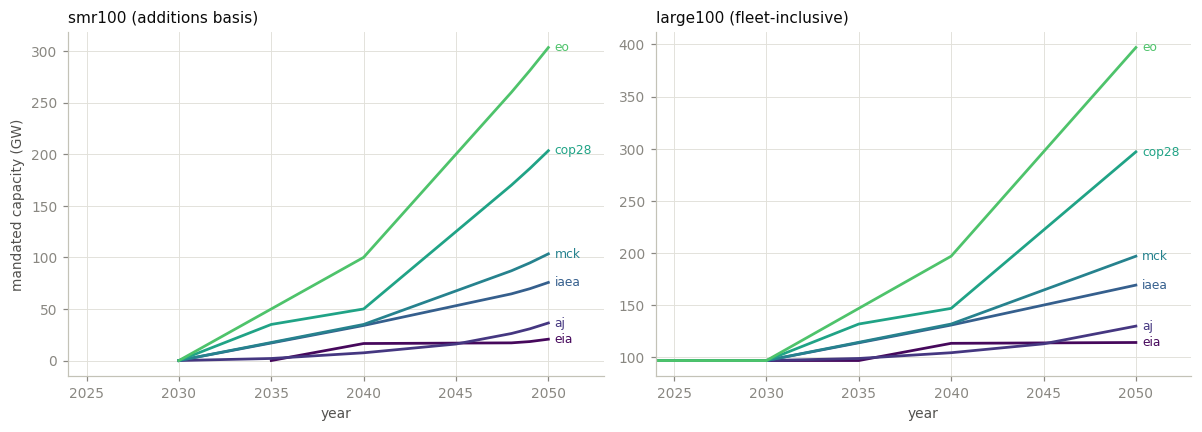

In [8]:
# ---- f01: the twelve mandate trajectories ------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, fam, ttl in [(axes[0], "smr", "smr100 (additions basis)"),
                     (axes[1], "large", "large100 (fleet-inclusive)")]:
    for s in SCHEDULES:
        cs = [c for c in (SMR_CASES if fam == "smr" else LARGE_CASES)
              if parse_case(c)[1] == s and parse_case(c)[3] != "eq"]
        tr = TRAJ[cs[0]] / 1e3
        tr = tr[tr.index >= 2024]
        nz = tr[tr > 0]
        if len(nz):                    # blank the pre-start zero run,
            tr = tr[tr.index >= int(nz.index.min()) - 1]  # keep one zero year
        ax.plot(tr.index, tr.values, color=SCHED_C[s], lw=1.8)
        ax.annotate(s, (tr.index[-1], tr.values[-1]), xytext=(4, 0),
                    textcoords="offset points", color=SCHED_C[s], fontsize=8, va="center")
    ax.set_title(ttl)
    ax.set_xlabel("year")
    ax.set_xlim(2024, 2053)
axes[0].set_ylabel("mandated capacity (GW)")
fig.tight_layout()
savefig(fig, "f01_mandate_trajectories.png")
plt.show()


In [9]:
# ---- objective sanity: p05 <= p50 <= p95 inside each schedule ----------------------
rows = []
for s in SCHEDULES:
    o = {p: OBJ[f"smr100_{s}_{p}"] for p in ("p05", "p50", "p95")}
    rows.append(dict(schedule=s, **{k: f"{v:.4e}" for k, v in o.items()},
                     ordered=bool(o["p05"] <= o["p50"] <= o["p95"])))
for s in SCHEDULES:
    o = {p: OBJ[f"large100_{s}_{p}"] for p in ("p05", "p50", "p95")}
    rows.append(dict(schedule=f"{s} (large)", **{k: f"{v:.4e}" for k, v in o.items()},
                     ordered=bool(o["p05"] <= o["p50"] <= o["p95"])))
obj_tbl = pd.DataFrame(rows)
assert obj_tbl["ordered"].all(), obj_tbl
print(obj_tbl.to_string(index=False))
print("objective is ordered p05 <= p50 <= p95 in all six schedules, both families.")


     schedule        p05        p50        p95  ordered
          eia 1.6171e+12 1.6319e+12 1.6494e+12     True
           aj 1.6139e+12 1.6562e+12 1.7004e+12     True
         iaea 1.5836e+12 1.6343e+12 1.6947e+12     True
          mck 1.5672e+12 1.6346e+12 1.7283e+12     True
        cop28 1.5060e+12 1.6468e+12 1.8132e+12     True
           eo 1.4470e+12 1.6255e+12 1.8856e+12     True
  eia (large) 1.6245e+12 1.6350e+12 1.6464e+12     True
   aj (large) 1.6362e+12 1.6636e+12 1.6988e+12     True
 iaea (large) 1.6083e+12 1.6476e+12 1.6920e+12     True
  mck (large) 1.6049e+12 1.6661e+12 1.7365e+12     True
cop28 (large) 1.5873e+12 1.7168e+12 1.8304e+12     True
   eo (large) 1.5690e+12 1.7212e+12 1.9051e+12     True
objective is ordered p05 <= p50 <= p95 in all six schedules, both families.


## S2 — Where the mandates bind, and where they do not

Adverse findings first. The floor does **not** bind everywhere:

- `smr100_eia_p05` (the cheap world on the least ambitious schedule) builds past
  the floor in one of its five mandated years. Peak overbuild is 3%.
- Every large100 case — all 18, at every percentile — has two clearly slack
  years (overbuild about 1%).
- Each `large100_eia_*` case has a positive dual in only 6 of its 12 mandated
  years, at every percentile. In the other years, the existing fleet plus
  voluntary builds already satisfy the fleet-inclusive floor at a near-zero
  dual. The other large100 schedules price 10 of 12.
- All other smr100 cases bind in every mandated year.

A slack year means the model builds past the floor on its own. The mandate is
locally redundant there, and the dual is zero by complementary slackness (the
QA notebook verified this both ways). The EIA schedule mandates only 5 model
years, because its additions trajectory starts in 2036 and the first solve year
after that is 2038.

The heatmap shows three mandated states. **Binding** means the dual is above
$1/MW-yr. **Clearly slack** means the capacity is more than 100 MW above the
floor. **Satisfied, near-zero dual** covers the years between: the floor holds
almost exactly, but it does not price. Those years occur in the large100 cases,
where the existing fleet path meets the early floor.

*Figure note (f02): mandate state by case and model year; each clearly-slack cell shows the delivered-capacity / floor ratio.*

*Figure note (f03): delivered capacity against the mandate floor (dotted step); open circles mark mandated years with a near-zero dual (orange edge in the smr100 row, blue edge in the large100 row).*

In [10]:
# ---- t02: slack years ---------------------------------------------------------------
slack = DUALS[DUALS["clearly_slack"]].copy()
slack["overbuild_ratio"] = (slack["cap_MW"] / slack["mandate_MW"]).round(3)
t02 = slack[["case", "t", "mandate_MW", "cap_MW", "slack_MW", "overbuild_ratio"]]
t02 = t02.sort_values(["case", "t"])
t02.to_csv(EXPORTS / "t02_slack_years.csv", index=False)
print(t02.to_string(index=False))
print(f"\n{len(t02)} clearly slack (case, year) points across the {len(CASES)} runs.")


              case    t  mandate_MW  cap_MW  slack_MW  overbuild_ratio
   large100_aj_p05 2026     97000.0 97636.7     636.7            1.007
   large100_aj_p05 2029     97000.0 97918.9     918.9            1.009
   large100_aj_p50 2026     97000.0 97636.7     636.7            1.007
   large100_aj_p50 2029     97000.0 97918.9     918.9            1.009
   large100_aj_p95 2026     97000.0 97636.7     636.7            1.007
   large100_aj_p95 2029     97000.0 97918.9     918.9            1.009
large100_cop28_p05 2026     97000.0 97636.7     636.7            1.007
large100_cop28_p05 2029     97000.0 97918.9     918.9            1.009
large100_cop28_p50 2026     97000.0 97636.7     636.7            1.007
large100_cop28_p50 2029     97000.0 97918.9     918.9            1.009
large100_cop28_p95 2026     97000.0 97636.7     636.7            1.007
large100_cop28_p95 2029     97000.0 97918.9     918.9            1.009
  large100_eia_p05 2026     97000.0 97636.7     636.7            1.007
  larg

saved -> figures\f02_binding_heatmap.png


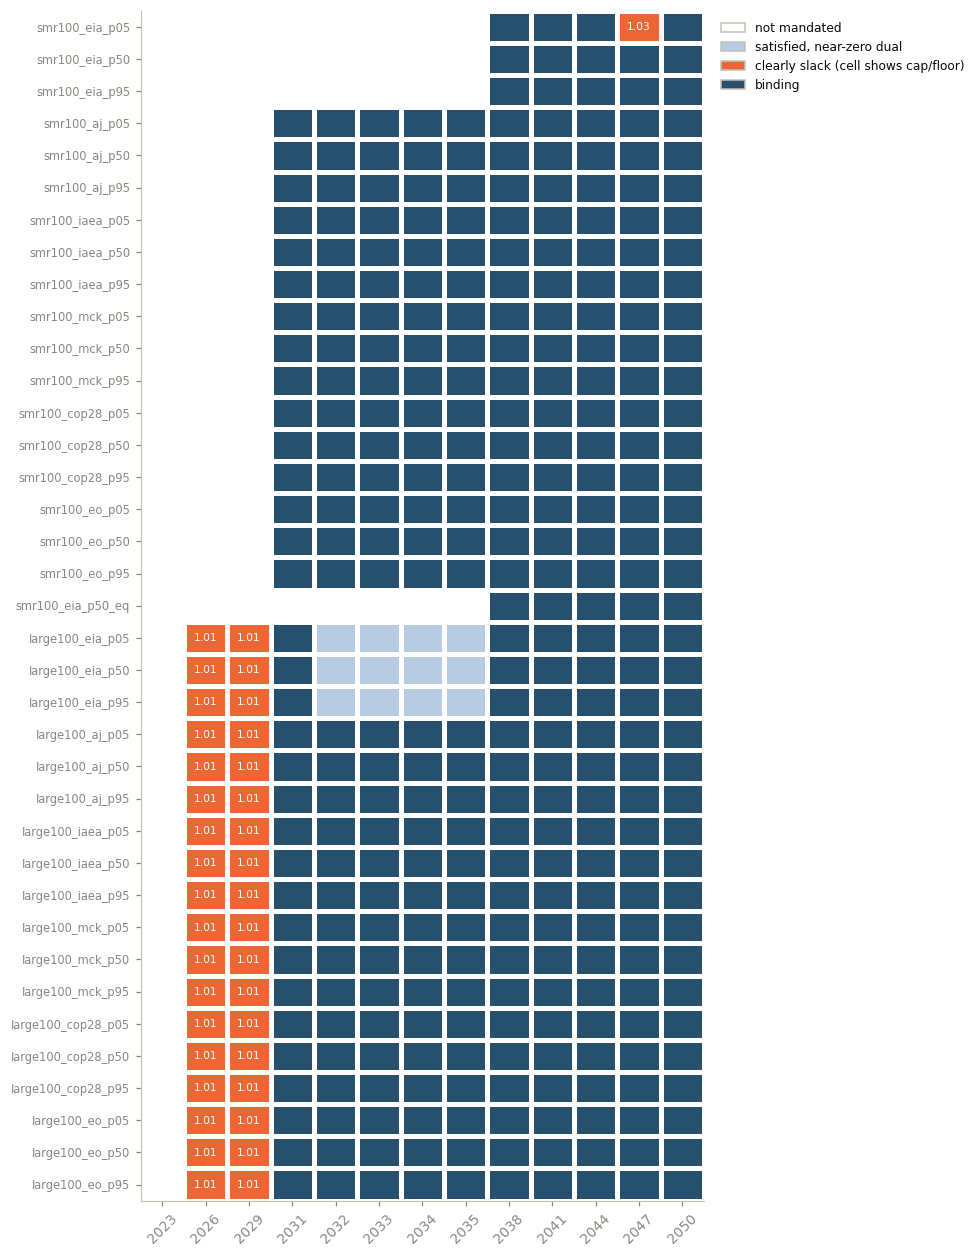

In [11]:
# ---- f02: binding-state heatmap ------------------------------------------------------
CASE_ORDER = ([f"smr100_{s}_{p}" for s in SCHEDULES for p in ("p05", "p50", "p95")]
              + ["smr100_eia_p50_eq"]
              + [f"large100_{s}_{p}" for s in SCHEDULES for p in ("p05", "p50", "p95")])
assert set(CASE_ORDER) == set(CASES)
myears = [t for t in YEARS_RUN if t >= 2023]
STATE = {"not mandated": 0, "satisfied, near-zero dual": 1, "clearly slack": 2, "binding": 3}
Z = np.zeros((len(CASE_ORDER), len(myears)))
du = DUALS.set_index(["case", "t"])
for i, c in enumerate(CASE_ORDER):
    for j, t in enumerate(myears):
        r = du.loc[(c, t)]
        if not r["mandated"]:
            Z[i, j] = STATE["not mandated"]
        elif r["binding"]:
            Z[i, j] = STATE["binding"]
        elif r["clearly_slack"]:
            Z[i, j] = STATE["clearly slack"]
        else:
            Z[i, j] = STATE["satisfied, near-zero dual"]
cmap = mpl.colors.ListedColormap([SURFACE, "#b8cbe4", "#eb6834", "#27506e"])
fig, ax = plt.subplots(figsize=(9, 11.5))
ax.pcolormesh(np.arange(len(myears) + 1), np.arange(len(CASE_ORDER) + 1), Z,
              cmap=cmap, vmin=-0.5, vmax=3.5, edgecolors=SURFACE, linewidth=2)
for i, c in enumerate(CASE_ORDER):        # annotate slack cells with overbuild ratio
    for j, t in enumerate(myears):
        r = du.loc[(c, t)]
        if r["mandated"] and r["clearly_slack"]:
            ax.text(j + 0.5, i + 0.5, f"{r['cap_MW'] / r['mandate_MW']:.2f}",
                    ha="center", va="center", fontsize=7, color=SURFACE)
ax.set_xticks(np.arange(len(myears)) + 0.5, myears, rotation=45)
ax.set_yticks(np.arange(len(CASE_ORDER)) + 0.5, CASE_ORDER, fontsize=7.5)
ax.invert_yaxis()
ax.grid(False)
handles = [mpl.patches.Patch(facecolor=cmap.colors[v], edgecolor=EDGE_C,
                             label=(k + " (cell shows cap/floor)"
                                    if k == "clearly slack" else k))
           for k, v in STATE.items()]
ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
fig.tight_layout()
savefig(fig, "f02_binding_heatmap.png")
plt.show()


saved -> figures\f03_mandate_vs_cap.png


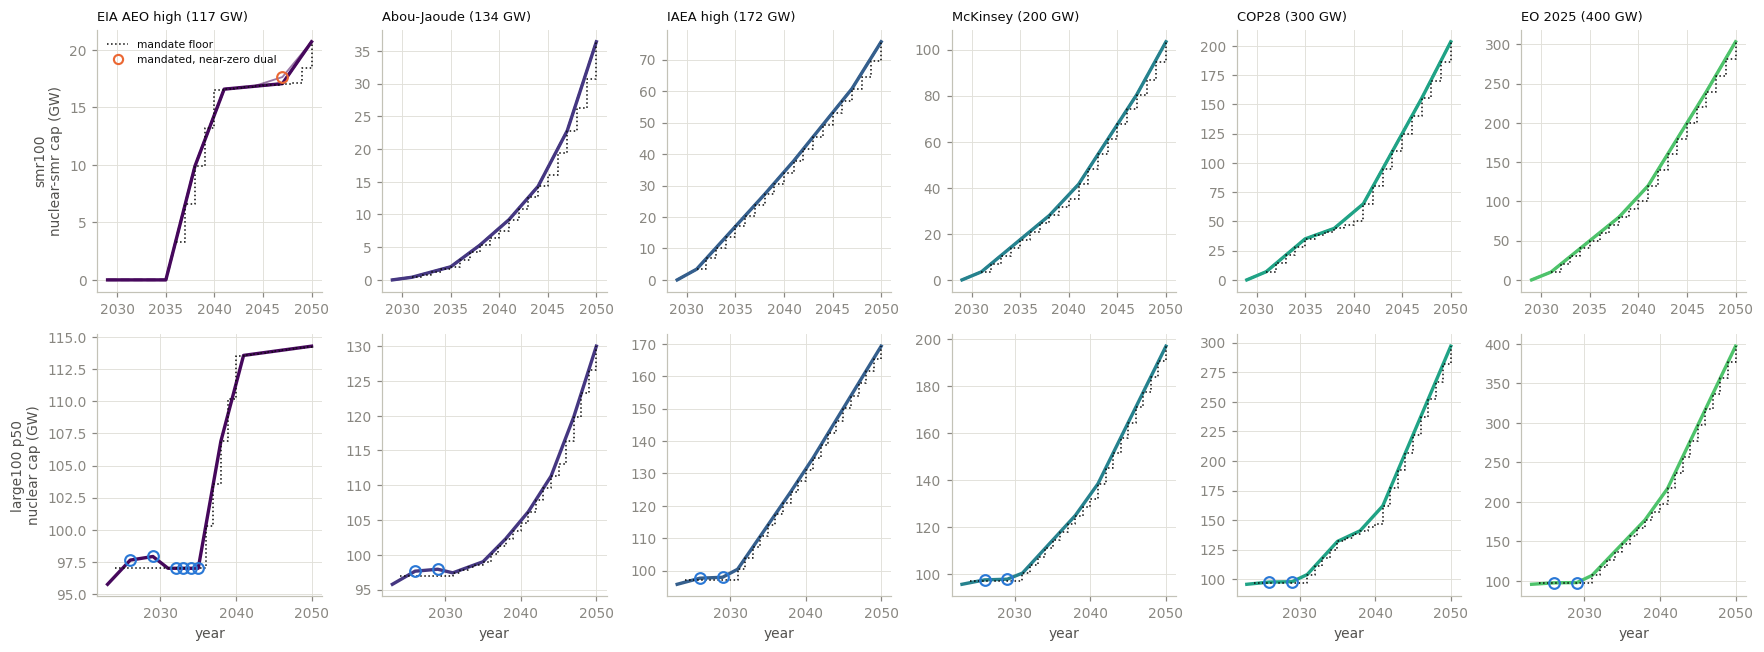

In [12]:
# ---- f03: mandate floor against delivered capacity ----------------------------------
fig, axes = plt.subplots(2, 6, figsize=(16, 6), sharex="row")
for j, s in enumerate(SCHEDULES):
    ax = axes[0, j]
    for p in ("p05", "p50", "p95"):
        c = f"smr100_{s}_{p}"
        d = DUALS[DUALS["case"] == c].set_index("t").sort_index()
        d = d[d.index >= 2029]
        ax.plot(d.index, d["cap_MW"] / 1e3, color=SCHED_C[s], **PCT_STYLE[p])
        sl = d[d["mandated"] & ~d["binding"]]
        ax.plot(sl.index, sl["cap_MW"] / 1e3, "o", mfc="none", mec=COL["smr"],
                ms=7, mew=1.4, zorder=5)
    tr = TRAJ[f"smr100_{s}_p50"] / 1e3
    tr = tr[(tr.index >= 2029) & (tr > 0)]
    ax.step(tr.index, tr.values, where="post", color=INK, lw=1.0, ls=":")
    ax.set_title(SCHED_LABEL[s], fontsize=8.5)
    if j == 0:
        ax.set_ylabel("smr100\nnuclear-smr cap (GW)")
for j, s in enumerate(SCHEDULES):
    ax = axes[1, j]
    c = f"large100_{s}_p50"
    d = DUALS[DUALS["case"] == c].set_index("t").sort_index()
    d = d[d.index >= 2023]
    ax.plot(d.index, d["cap_MW"] / 1e3, color=SCHED_C[s], **PCT_STYLE["p50"])
    sl = d[d["mandated"] & ~d["binding"]]
    ax.plot(sl.index, sl["cap_MW"] / 1e3, "o", mfc="none", mec=COL["large"],
            ms=7, mew=1.4, zorder=5)
    tr = TRAJ[c] / 1e3
    tr = tr[(tr.index >= 2023) & (tr > 0)]
    ax.step(tr.index, tr.values, where="post", color=INK, lw=1.0, ls=":")
    ax.set_xlabel("year")
    if j == 0:
        ax.set_ylabel("large100 p50\nnuclear cap (GW)")
axes[0, 0].legend(
    [mpl.lines.Line2D([], [], color=INK, lw=1.0, ls=":"),
     mpl.lines.Line2D([], [], marker="o", mfc="none", mec=COL["smr"],
                      mew=1.4, ls="none")],
    ["mandate floor", "mandated, near-zero dual"], fontsize=7, loc="upper left")
fig.tight_layout()
savefig(fig, "f03_mandate_vs_cap.png")
plt.show()


## S3 — Dual price trajectories

The dual of the mandate constraint is a rental price. Its unit is dollars per
MW and year, because the floor is on cumulative national capacity in each year.
The h5 key is `nuclear_cap_price(t)`, in dollars of 2004. The figures show
dollars of 2024 per kW and year.

**Read the level as total support.** The production baseline removes the
nuclear ITC (`incentives_suffix=obbba_nonuclearitc`; QA tests B10-B13 verified
this). Thus the dual is the total support the mandated technology needs in that
year. It is not an increment on top of the 48E credit.

Known structure, re-verified below: the dual is monotone in the cost world
(p95 >= p50 >= p05 in every year, no crossing). The p05 duals decay hard toward
zero. The p95 duals stay close to flat. At p50, the large100 comparators need
about 1.2x to 1.4x the smr100 dual in shared binding years. The percentile
arm (t15, Step 4 delivery) shows this ratio is cost-world dependent: about
1.4x to 3.5x at p05, and near parity (0.95x to 1.02x) at p95.

The equality copy `smr100_eia_p50_eq` duplicates `smr100_eia_p50` (section S9).
The fans exclude it.

*Figure note (f04): mandate dual trajectories — percentile fans per schedule, with the large100 percentile band dashed.*

*Figure note (f05): the six smr100 p50 dual paths on one panel.*

In [13]:
# ---- t03: dual summary per case ------------------------------------------------------
KWYR = 1e-3      # $/MW-yr -> $/kW-yr
rows = []
for c in CASES:
    d = DUALS[(DUALS["case"] == c) & DUALS["mandated"]].set_index("t").sort_index()
    b = d[d["binding"]]["dual_2024_MWyr"]
    rows.append(dict(
        case=c,
        n_binding=len(b),
        mean_binding_dual_2024_kWyr=round(float(b.mean()) * KWYR, 1) if len(b) else 0.0,
        peak_dual_2024_kWyr=round(float(b.max()) * KWYR, 1) if len(b) else 0.0,
        peak_year=int(b.idxmax()) if len(b) else None,
        dual_2050_2024_kWyr=round(float(d.loc[2050, "dual_2024_MWyr"]) * KWYR, 1)
                            if 2050 in d.index else 0.0,
    ))
t03 = pd.DataFrame(rows)
t03.to_csv(EXPORTS / "t03_dual_summary.csv", index=False)
print(t03.to_string(index=False))

# pointwise monotonicity across the cost world, re-verified from the export
for s in SCHEDULES:
    piv = (DUALS[(DUALS["family"] == "smr") & (DUALS["schedule"] == s)
                 & (DUALS["variant"] != "eq")]
           .pivot_table(index="t", columns="pct", values="dual_2004_MWyr"))
    assert ((piv["p95"] >= piv["p50"] - 1e-6) & (piv["p50"] >= piv["p05"] - 1e-6)).all(), s
for s in SCHEDULES:
    piv = (DUALS[(DUALS["family"] == "large") & (DUALS["schedule"] == s)]
           .pivot_table(index="t", columns="pct", values="dual_2004_MWyr"))
    assert ((piv["p95"] >= piv["p50"] - 1e-6) & (piv["p50"] >= piv["p05"] - 1e-6)).all(), s
print("dual is monotone p95 >= p50 >= p05 pointwise in all six schedules, "
      "both families.")


              case  n_binding  mean_binding_dual_2024_kWyr  peak_dual_2024_kWyr  peak_year  dual_2050_2024_kWyr
    smr100_eia_p05          4                         70.1                176.5       2038                  4.4
    smr100_eia_p50          5                        334.4                405.9       2038                310.2
    smr100_eia_p95          5                        610.1                693.0       2038                581.3
     smr100_aj_p05         10                        200.6                370.7       2031                 69.0
     smr100_aj_p50         10                        389.7                441.1       2033                368.1
     smr100_aj_p95         10                        698.1                758.6       2033                627.7
   smr100_iaea_p05         10                        117.8                305.5       2031                 58.9
   smr100_iaea_p50         10                        370.8                746.4       2031              

saved -> figures\f04_dual_fans.png


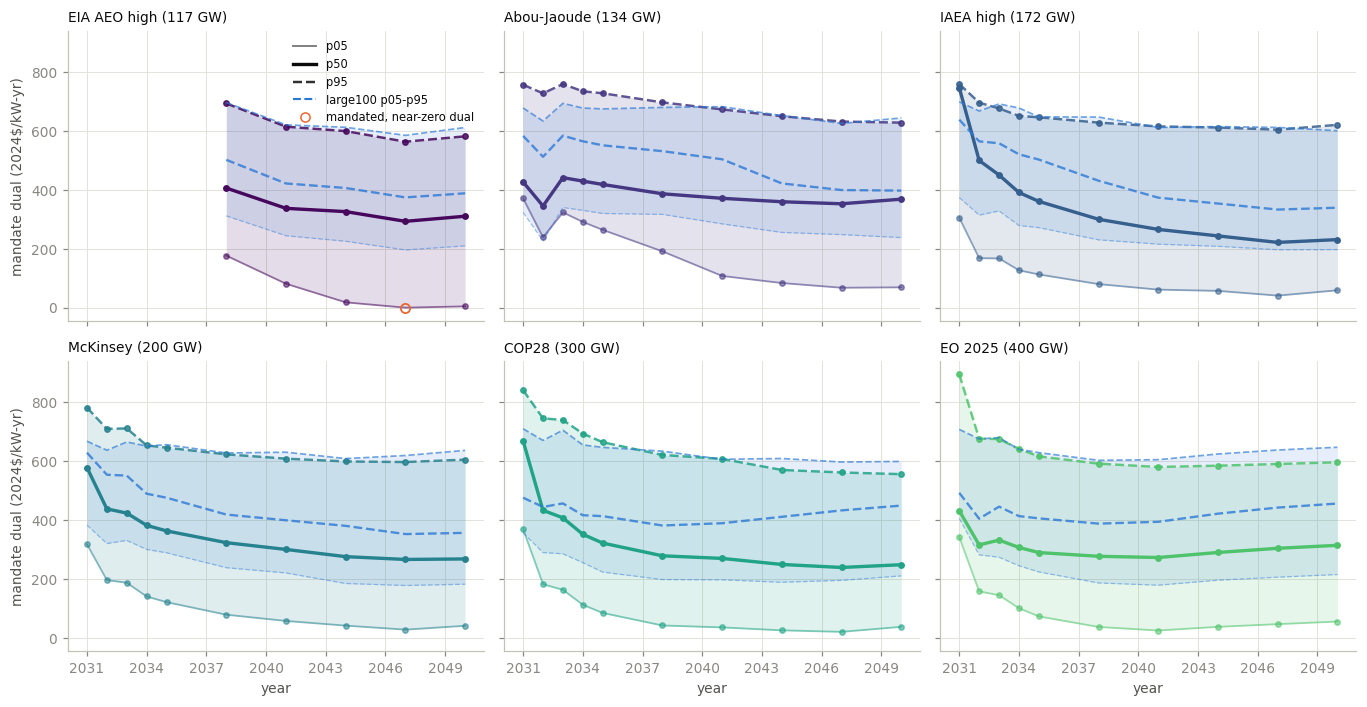

In [14]:
# ---- f04: dual fans per schedule, large100 overlay -----------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.5), sharex=True, sharey=True)
for k, s in enumerate(SCHEDULES):
    ax = axes.flat[k]
    piv = (DUALS[(DUALS["family"] == "smr") & (DUALS["schedule"] == s)
                 & (DUALS["variant"] != "eq") & (DUALS["t"] >= 2029)
                 & DUALS["in_program"]]         # blank, not zero, before builds
           .pivot_table(index="t", columns="pct", values="dual_2024_MWyr") * KWYR)
    ax.fill_between(piv.index, piv["p05"], piv["p95"], color=SCHED_C[s], alpha=0.14, lw=0)
    for p in ("p05", "p50", "p95"):
        ax.plot(piv.index, piv[p], color=SCHED_C[s], **PCT_STYLE[p])
        dd = DUALS[(DUALS["case"] == f"smr100_{s}_{p}") & (DUALS["t"] >= 2029)
                   & DUALS["in_program"]]
        bind = dd[dd["binding"]]
        ax.plot(bind["t"], bind["dual_2024_MWyr"] * KWYR, "o", ms=3.5,
                color=SCHED_C[s], alpha=PCT_STYLE[p]["alpha"])
        zz = dd[~dd["binding"]]
        ax.plot(zz["t"], zz["dual_2024_MWyr"] * KWYR, "o", ms=6, mfc="none",
                mec=COL["smr"], mew=1.2, zorder=5)
    pivL = (DUALS[(DUALS["family"] == "large") & (DUALS["schedule"] == s)
                  & (DUALS["t"] >= 2029) & DUALS["in_program"]]
            .pivot_table(index="t", columns="pct", values="dual_2024_MWyr") * KWYR)
    ax.fill_between(pivL.index, pivL["p05"], pivL["p95"], color=COL["large"],
                    alpha=0.12, lw=0)
    for p in ("p05", "p50", "p95"):
        ax.plot(pivL.index, pivL[p], color=COL["large"], ls="--",
                lw=PCT_STYLE[p]["lw"] * 0.7, alpha=PCT_STYLE[p]["alpha"] * 0.8)
    ax.set_title(SCHED_LABEL[s], fontsize=9)
    if k % 3 == 0:
        ax.set_ylabel("mandate dual (2024$/kW-yr)")
    if k >= 3:
        ax.set_xlabel("year")
handles = ([mpl.lines.Line2D([], [], color=INK, **{k: v for k, v in PCT_STYLE[p].items()})
            for p in ("p05", "p50", "p95")]
           + [mpl.lines.Line2D([], [], color=COL["large"], lw=1.4, ls="--"),
              mpl.lines.Line2D([], [], marker="o", mfc="none", mec=COL["smr"], ls="none")])
axes.flat[0].legend(handles, ["p05", "p50", "p95", "large100 p05-p95", "mandated, near-zero dual"],
                    fontsize=7.5, loc="upper right")
for ax in axes.flat:   # integer year ticks (fractional after masking)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
fig.tight_layout()
savefig(fig, "f04_dual_fans.png")
plt.show()


saved -> figures\f05_dual_all_p50.png


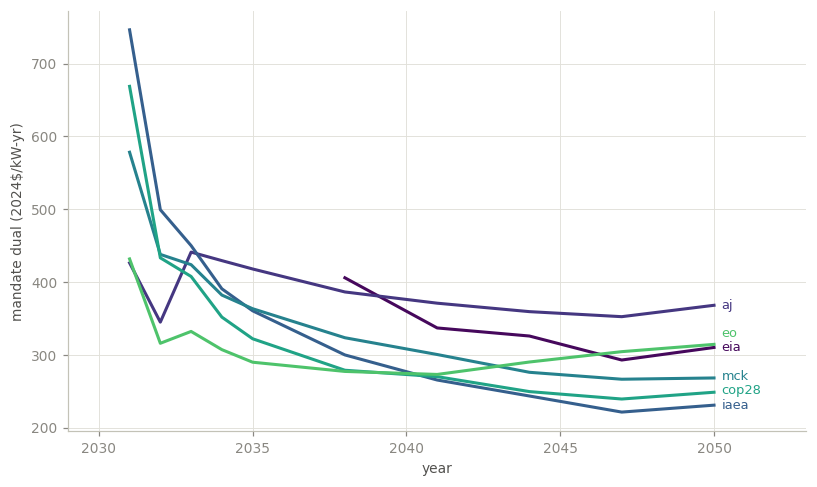

In [15]:
# ---- f05: all six smr100 p50 dual paths on one panel ----------------------------------
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ends = {}
for s in SCHEDULES:
    d = (DUALS[(DUALS["case"] == f"smr100_{s}_p50") & (DUALS["t"] >= 2029)
               & DUALS["in_program"]]        # blank, not zero, before builds
         .set_index("t")["dual_2024_MWyr"] * KWYR)
    ax.plot(d.index, d.values, color=SCHED_C[s], lw=2.0)
    ends[s] = float(d.values[-1])
# end labels, dodged upward so near-equal endpoints (eo vs eia) never overprint
min_gap = 0.035 * (ax.get_ylim()[1] - ax.get_ylim()[0])
pos, prev = {}, None
for s in sorted(ends, key=ends.get):
    pos[s] = ends[s] if prev is None else max(ends[s], prev + min_gap)
    prev = pos[s]
for s in SCHEDULES:
    ax.annotate(s, (2050, pos[s]), xytext=(5, 0), textcoords="offset points",
                color=SCHED_C[s], fontsize=8.5, va="center")
ax.set_xlabel("year")
ax.set_ylabel("mandate dual (2024$/kW-yr)")
ax.set_xlim(2029, 2053)
fig.tight_layout()
savefig(fig, "f05_dual_all_p50.png")
plt.show()


## S4 — Dual price against schedule ambition

The cross-section plots the mean binding dual of each case against the 2050
ambition of its schedule (117 to 400 GW).

At p50, the mean binding dual **rises** from EIA (117 GW) to Abou-Jaoude
(134 GW), and then **falls** through the more ambitious schedules down to the
EO 2025 schedule (400 GW). More deployment pushes the fleet further down the
learning curve, so the rental price of the marginal mandated MW falls even as
the mandated quantity rises. This is the learning mechanism in cross-section.

**Caveat.** The points differ in the drawn cost world as well as in ambition.
Each schedule carries its own percentile draw of its own program. The line is
descriptive. It is not a supply curve.

*Figure note (f06): mean binding dual against 2050 schedule ambition; orange circles = smr100, blue squares (dashed) = large100.*

saved -> figures\f06_dual_vs_ambition.png


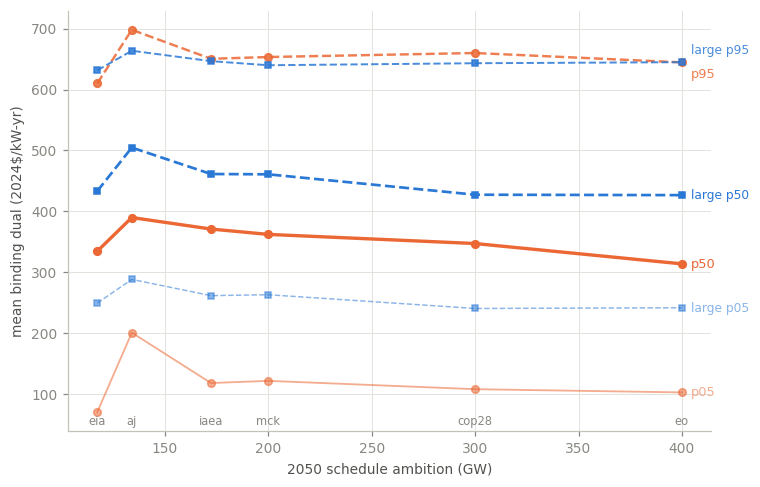

large100 / smr100 mean binding dual ratio at p50 (note: bases differ; shared-binding-year ratio in the QA report is 1.23-1.36): {'eia': 1.3, 'aj': 1.29, 'iaea': 1.24, 'mck': 1.27, 'cop28': 1.23, 'eo': 1.36}


In [16]:
# ---- f06 + cross-section table --------------------------------------------------------
t03i = t03.set_index("case")
fig, ax = plt.subplots(figsize=(7, 4.5))
xs = [SCHED_GW[s] for s in SCHEDULES]
for p in ("p05", "p50", "p95"):
    ys = [t03i.loc[f"smr100_{s}_{p}", "mean_binding_dual_2024_kWyr"] for s in SCHEDULES]
    ax.plot(xs, ys, marker="o", ms=5, color=COL["smr"], **{k: v for k, v in
            PCT_STYLE[p].items() if k != "ls"}, ls=PCT_STYLE[p]["ls"])
    ax.annotate(p, (xs[-1], ys[-1]), xytext=(6, -8 if p == "p95" else 0),
                textcoords="offset points",
                color=COL["smr"], alpha=PCT_STYLE[p]["alpha"], fontsize=8.5, va="center")
for p in ("p05", "p50", "p95"):
    ys_l = [t03i.loc[f"large100_{s}_{p}", "mean_binding_dual_2024_kWyr"]
            for s in SCHEDULES]
    ax.plot(xs, ys_l, marker="s", ms=4, color=COL["large"], ls="--",
            lw=PCT_STYLE[p]["lw"] * 0.8, alpha=PCT_STYLE[p]["alpha"])
    ax.annotate(f"large {p}", (xs[-1], ys_l[-1]),
                xytext=(6, 8 if p == "p95" else 0),
                textcoords="offset points", color=COL["large"], fontsize=8,
                va="center", alpha=PCT_STYLE[p]["alpha"])
for s in SCHEDULES:
    ax.annotate(s, (SCHED_GW[s], ax.get_ylim()[0]), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=7.5, color=FAINT)
ax.set_xlabel("2050 schedule ambition (GW)")
ax.set_ylabel("mean binding dual (2024$/kW-yr)")
fig.tight_layout()
savefig(fig, "f06_dual_vs_ambition.png")
plt.show()

ratio = {s: round(t03i.loc[f"large100_{s}_p50", "mean_binding_dual_2024_kWyr"]
                  / t03i.loc[f"smr100_{s}_p50", "mean_binding_dual_2024_kWyr"], 2)
         for s in SCHEDULES}
print("large100 / smr100 mean binding dual ratio at p50 (note: bases differ; "
      "shared-binding-year ratio in the QA report is 1.23-1.36):", ratio)


### t15 + f15 — the large100 percentile band against the smr100 band

The Step 3 finding to generalize (M5-b): at p50 the large100 comparators need
about 1.2x to 1.4x the smr100 dual on shared binding years. With the percentile
arm complete, t15 recomputes that ratio at p05 and p95, and f15 draws the two
families' dual bands per schedule (the paper's Fig 6 panel c). The conditional
what-if caveat stands: the two families differ in mandated technology, mandate
basis, and drawn world.

*Figure note (f15): required-subsidy bands per schedule — shaded band = the family's p05–p95 percentile range, line = p50.*

large100 / smr100 mean binding dual ratio (shared binding years):
pct        p05   p50   p95
schedule                  
eia       3.53  1.25  1.02
aj        1.44  1.29  0.95
iaea      2.22  1.24  0.99
mck       2.17  1.27  0.98
cop28     2.23  1.23  0.97
eo        2.36  1.36  1.00


saved -> figures\f15_large_band.png


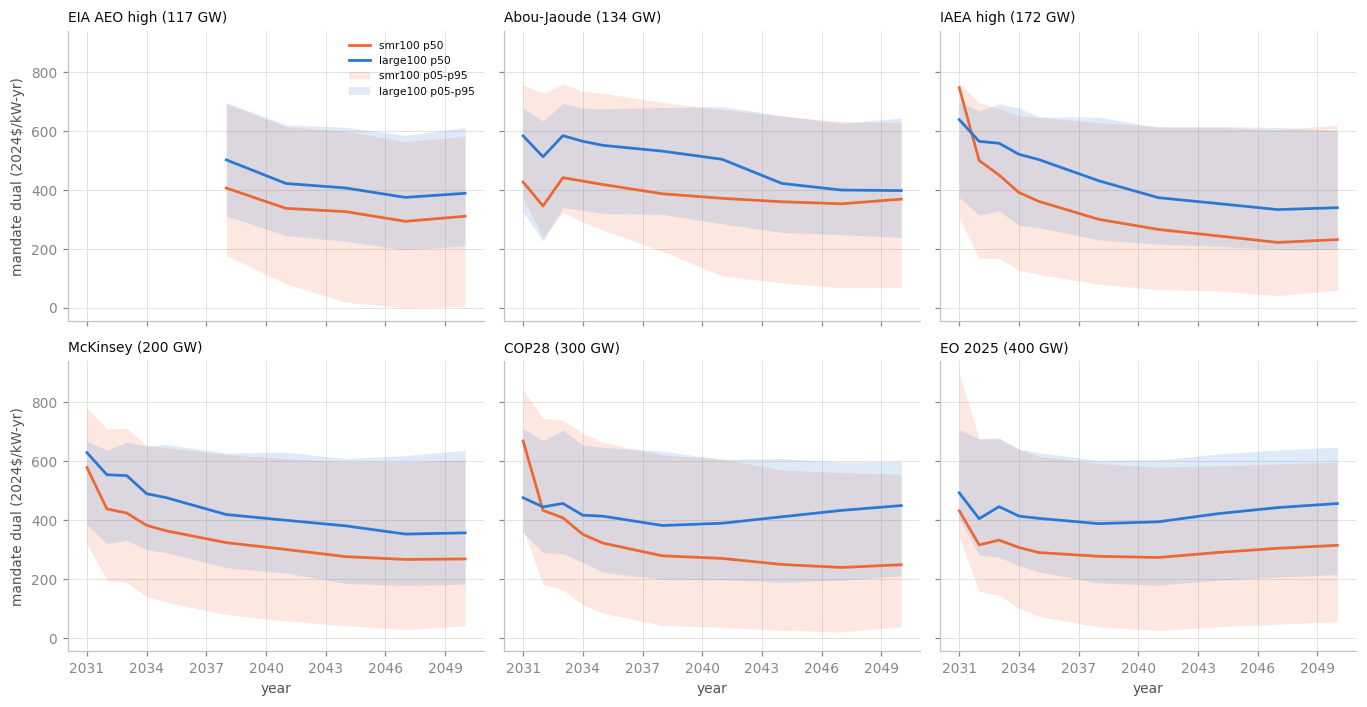

In [17]:
# ---- t15 + f15: large100 percentile band against the smr100 band (M5-b) ---------------
rows15 = []
for s in SCHEDULES:
    for p in ("p05", "p50", "p95"):
        dl = (DUALS[(DUALS["case"] == f"large100_{s}_{p}") & DUALS["binding"]]
              .set_index("t")["dual_2024_MWyr"])
        ds = (DUALS[(DUALS["case"] == f"smr100_{s}_{p}") & DUALS["binding"]]
              .set_index("t")["dual_2024_MWyr"])
        shared = sorted(set(dl.index) & set(ds.index))
        rows15.append(dict(
            schedule=s, pct=p, n_shared_binding=len(shared),
            large_mean_2024_kWyr=(round(float(dl.reindex(shared).mean()) * KWYR, 1)
                                  if shared else None),
            smr_mean_2024_kWyr=(round(float(ds.reindex(shared).mean()) * KWYR, 1)
                                if shared else None),
            ratio_large_over_smr=(round(float(dl.reindex(shared).mean()
                                              / ds.reindex(shared).mean()), 2)
                                  if shared else None)))
t15 = pd.DataFrame(rows15)
t15.to_csv(EXPORTS / "t15_large_ratio.csv", index=False)
piv15 = (t15.pivot_table(index="schedule", columns="pct", values="ratio_large_over_smr")
         .reindex(SCHEDULES))
print("large100 / smr100 mean binding dual ratio (shared binding years):")
print(piv15.to_string())

# f15: the two families' dual bands per schedule (Fig 6 panel c)
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.5), sharex=True, sharey=True)
for k, s in enumerate(SCHEDULES):
    ax = axes.flat[k]
    for fam, colr in (("smr", COL["smr"]), ("large", COL["large"])):
        piv = (DUALS[(DUALS["family"] == fam) & (DUALS["schedule"] == s)
                     & (DUALS["variant"] != "eq") & (DUALS["t"] >= 2029)
                     & DUALS["in_program"]]     # blank, not zero, before builds
               .pivot_table(index="t", columns="pct", values="dual_2024_MWyr") * KWYR)
        ax.fill_between(piv.index, piv["p05"], piv["p95"], color=colr, alpha=0.15, lw=0)
        ax.plot(piv.index, piv["p50"], color=colr, lw=1.8,
                label=f"{fam}100 p50" if k == 0 else None)
    ax.set_title(SCHED_LABEL[s], fontsize=9)
    if k % 3 == 0:
        ax.set_ylabel("mandate dual (2024$/kW-yr)")
    if k >= 3:
        ax.set_xlabel("year")
h15, l15 = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend(
    h15 + [mpl.patches.Patch(facecolor=COL["smr"], alpha=0.15),
           mpl.patches.Patch(facecolor=COL["large"], alpha=0.15)],
    l15 + ["smr100 p05-p95", "large100 p05-p95"], fontsize=7)
for ax in axes.flat:   # integer year ticks (fractional after masking)
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
fig.tight_layout()
savefig(fig, "f15_large_band.png")
plt.show()


## S5 — Bridge shape: dual decay metrics

The working hypothesis of the paper is that the subsidy is a **bridge**: the
dual should decay toward zero as the fleet walks down the learning curve. The
shape of the dual trajectory, not its level, is the durable object.

The metrics below quantify the shape per case: the peak year, the ratio of the
2050 dual to the peak dual, the first year below half of the peak, and the
count of zero-dual mandated years.

**Adverse side, with equal prominence:** in the p95 (expensive) worlds the dual
does **not** decay by 2050. The bridge does not come down inside the model
horizon in those draws. The decay result holds in the p05 worlds and, more
weakly, at p50.

*Figure note (f07): dual decay normalized to each case's peak, one panel per percentile; solid = smr100, dashed = large100 comparators.*

In [18]:
# ---- t04: bridge metrics --------------------------------------------------------------
rows = []
for c in CASES:
    d = DUALS[(DUALS["case"] == c) & DUALS["mandated"]].set_index("t").sort_index()
    b = d[d["binding"]]["dual_2004_MWyr"]
    if not len(b):
        rows.append(dict(case=c, peak_year=None, end_over_peak=None,
                         first_year_below_half_peak=None,
                         n_zero_dual_mandated_years=int((~d["binding"]).sum())))
        continue
    peak_t, peak = int(b.idxmax()), float(b.max())
    end = float(d.loc[2050, "dual_2004_MWyr"]) if 2050 in d.index else 0.0
    below = [t for t in b.index if t > peak_t and b[t] < 0.5 * peak]
    zero_after = [t for t in d.index if t > peak_t and not d.loc[t, "binding"]]
    first_half = min(below + zero_after) if (below or zero_after) else None
    rows.append(dict(case=c, peak_year=peak_t, end_over_peak=round(end / peak, 2),
                     first_year_below_half_peak=first_half,
                     n_zero_dual_mandated_years=int((~d["binding"]).sum())))
t04 = pd.DataFrame(rows)
t04.to_csv(EXPORTS / "t04_bridge_metrics.csv", index=False)
print(t04.to_string(index=False))


              case  peak_year  end_over_peak  first_year_below_half_peak  n_zero_dual_mandated_years
    smr100_eia_p05       2038           0.03                      2041.0                           1
    smr100_eia_p50       2038           0.76                         NaN                           0
    smr100_eia_p95       2038           0.84                         NaN                           0
     smr100_aj_p05       2031           0.19                      2041.0                           0
     smr100_aj_p50       2033           0.83                         NaN                           0
     smr100_aj_p95       2033           0.83                         NaN                           0
   smr100_iaea_p05       2031           0.19                      2034.0                           0
   smr100_iaea_p50       2031           0.31                      2035.0                           0
   smr100_iaea_p95       2031           0.82                         NaN                   

saved -> figures\f07_dual_shape_normalized.png


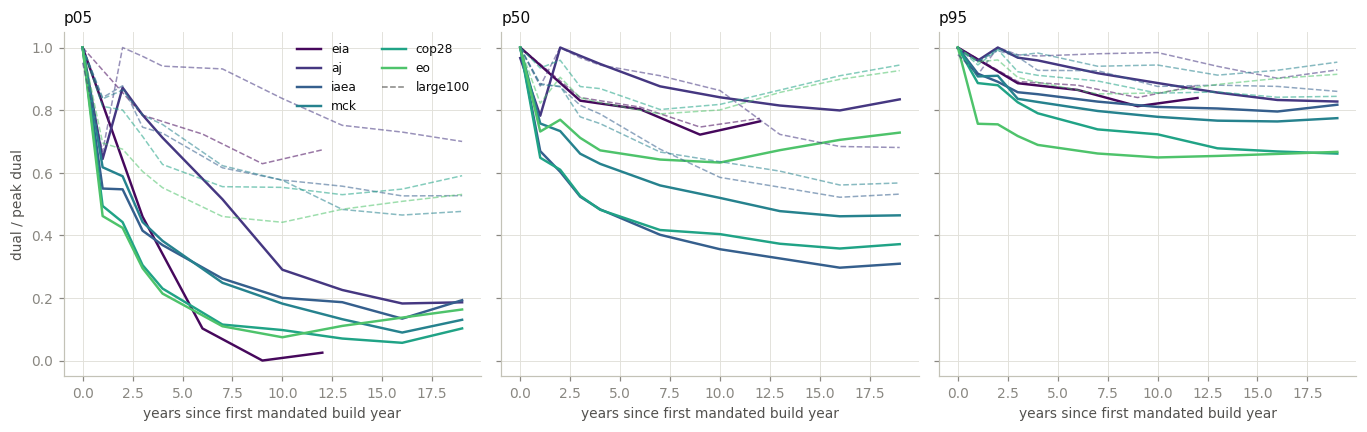

In [19]:
# ---- f07: normalized decay curves -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4), sharey=True)
for k, p in enumerate(("p05", "p50", "p95")):
    ax = axes[k]
    for s in SCHEDULES:
        c = f"smr100_{s}_{p}"
        d = DUALS[(DUALS["case"] == c) & DUALS["in_program"]].set_index("t").sort_index()
        peak = d["dual_2004_MWyr"].max()
        if peak <= 1.0:
            continue
        x = d.index - d.index.min()
        ax.plot(x, d["dual_2004_MWyr"] / peak, color=SCHED_C[s], lw=1.6,
                label=s if k == 0 else None)
    for s in SCHEDULES:     # large100 comparators share each panel, dashed
        c = f"large100_{s}_{p}"
        d = DUALS[(DUALS["case"] == c) & DUALS["in_program"]].set_index("t").sort_index()
        peak = d["dual_2004_MWyr"].max()
        if peak <= 1.0:
            continue
        x = d.index - d.index.min()
        ax.plot(x, d["dual_2004_MWyr"] / peak, color=SCHED_C[s], lw=1.0,
                ls="--", alpha=0.55)
    ax.set_title(p)
    ax.set_xlabel("years since first mandated build year")
axes[0].set_ylabel("dual / peak dual")
h7, l7 = axes[0].get_legend_handles_labels()
axes[0].legend(h7 + [mpl.lines.Line2D([], [], color=MUTED, lw=1.0, ls="--",
                                      alpha=0.7)],
               l7 + ["large100"], fontsize=8, ncols=2)
fig.tight_layout()
savefig(fig, "f07_dual_shape_normalized.png")
plt.show()


## S6 — System costs

**There is no no-mandate baseline run.** All 25 runs carry a mandate. Thus the
system cost *of the mandate* is not computable here as a difference against a
counterfactual. Four objects are computable and shown:

1. Cost levels per case (descriptive; the conflation caveat applies across
   schedules).
2. The p95 - p05 spread inside one schedule. The mandate is identical inside a
   schedule, so this spread isolates the drawn cost world.
3. The smr100 - large100 difference at p50 per schedule. These runs differ in
   the mandated technology, the mandate basis, and the drawn world. Read them
   as conditional what-ifs.
4. The fiscal bill of the mandate from the duals (section S8). That is the
   marginal-price measure of what the mandate costs to enforce.

The 25 `systemcost` streams group into seven buckets. Policy credit streams
(ITC / PTC / CO2 / H2-PTC payments) are negative. The total keeps their sign.
The per-year LP objective `z_rep` is not an annual cost stream: in the
sequential solve it mixes lump investment with operations weighted by
`pvf_onm` (about 14.76). This notebook uses `systemcost` only.

*Figure note (f08): system cost anatomy of the reference case `smr100_eia_p50`.*

*Figure note (f09): total annual system cost — percentile fans per schedule; cross-schedule levels mix mandate and drawn world.*

*Figure note (f10): panel a — p95 − p05 annual cost spread (same mandate, so the drawn world is isolated; solid = smr100, dashed = large100); panel b — smr100 − large100 annual cost at p50 (a conditional what-if).*

In [20]:
# ---- bucket the 25 streams --------------------------------------------------------------
BUCKETS = {
    "generation capex": ["inv_investment_capacity_costs",
                         "inv_investment_refurbishment_capacity",
                         "inv_investment_spurline_costs_rsc_technologies"],
    "transmission capex": ["inv_transmission_interzone_ac_investment",
                           "inv_transmission_interzone_dc_investment",
                           "inv_transmission_intrazone_investment"],
    "converter + H2 capex": ["inv_converter_costs", "inv_h2_production", "inv_h2_storage"],
    "fuel": ["op_fuelcosts_objfn"],
    "FOM": ["op_fom_costs", "op_consume_fom", "op_spurline_fom",
            "op_transmission_fom", "op_transmission_intrazone_fom"],
    "VOM + other op": ["op_vom_costs", "op_startcost", "op_acp_compliance_costs",
                       "op_co2_transport_storage", "op_h2_storage",
                       "op_h2_transport_intrareg"],
    "policy credits (neg.)": ["inv_itc_payments_negative", "op_co2_incentive_negative",
                              "op_h2_ptc_payments_negative", "op_ptc_payments_negative"],
}
covered = sorted(x for v in BUCKETS.values() for x in v)
assert covered == STREAMS, set(STREAMS) ^ set(covered)
S2B = {x: b for b, v in BUCKETS.items() for x in v}

SYSCOST["bucket"] = SYSCOST["sys_costs"].map(S2B)
SYSCOST["B2024"] = SYSCOST["Value"] * TO2024 / 1e9
CB = (SYSCOST.groupby(["case", "bucket", "t"], as_index=False)["B2024"].sum())
CTOT = SYSCOST.groupby(["case", "t"])["B2024"].sum().unstack("t")     # 2024$B per year
CB.to_csv(EXPORTS / "t05_systemcost_by_case.csv", index=False)

# consistency: raw_inv/raw_op against the stream sums (context, not a gate)
inv_streams = [x for x in STREAMS if x.startswith("inv_") and not x.endswith("negative")]
c = REF
si = SYSCOST[(SYSCOST["case"] == c) & SYSCOST["sys_costs"].isin(inv_streams)]
si = si.groupby("t")["Value"].sum()
ri = RAWIO[c][0].reindex(si.index)
print(f"{c}: raw_inv_cost vs positive inv streams, max rel diff "
      f"{float(((si - ri).abs() / ri.clip(lower=1)).max()):.2e}")
itc_mag = {k: abs(v) * TO2024 / 1e9 for k, v in ITC_TOT.items()}
print(f"ITC tax expenditure magnitude (2024$B, recorded negative in the h5): "
      f"{min(itc_mag.values()):.1f} .. {max(itc_mag.values()):.1f} "
      "- other techs keep their ITC; nuclear has none (QA B10-B13).")


smr100_eia_p50: raw_inv_cost vs positive inv streams, max rel diff 1.70e-01
ITC tax expenditure magnitude (2024$B, recorded negative in the h5): 205.0 .. 207.1 - other techs keep their ITC; nuclear has none (QA B10-B13).


saved -> figures\f08_cost_decomposition_ref.png


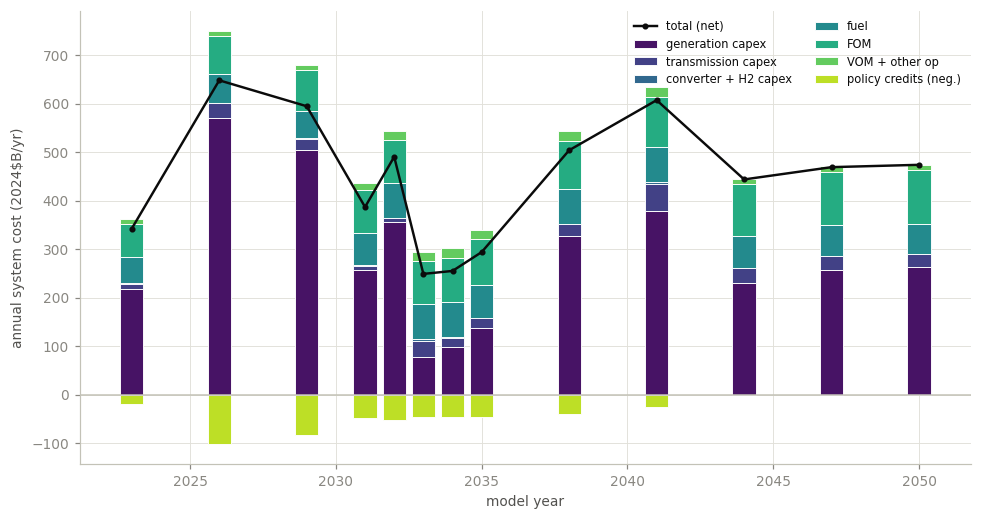

In [21]:
# ---- f08: cost anatomy of the reference case ----------------------------------------------
ref = CB[(CB["case"] == REF) & (CB["t"] >= 2023)].pivot_table(
    index="t", columns="bucket", values="B2024")
order = [b for b in BUCKETS if b in ref.columns]
bcol = {b: c for b, c in zip(BUCKETS, mpl.cm.viridis(np.linspace(0.05, 0.9, len(BUCKETS))))}
fig, ax = plt.subplots(figsize=(9, 4.8))
bottom_pos = np.zeros(len(ref))
bottom_neg = np.zeros(len(ref))
for b in order:
    v = ref[b].fillna(0).to_numpy()
    base = np.where(v >= 0, bottom_pos, bottom_neg)
    ax.bar(ref.index, v, bottom=base, width=0.8, label=b, color=bcol[b],
           edgecolor=SURFACE, linewidth=0.6)
    bottom_pos += np.clip(v, 0, None)
    bottom_neg += np.clip(v, None, 0)
tot = ref.sum(axis=1)
ax.plot(ref.index, tot, color=INK, lw=1.6, marker="o", ms=3, label="total (net)")
ax.axhline(0, color=EDGE_C, lw=1)
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=11))  # ticks below 0 too
ax.set_xlabel("model year")
ax.set_ylabel("annual system cost (2024$B/yr)")
ax.legend(fontsize=7.5, ncols=2)
fig.tight_layout()
savefig(fig, "f08_cost_decomposition_ref.png")
plt.show()


saved -> figures\f09_cost_totals.png


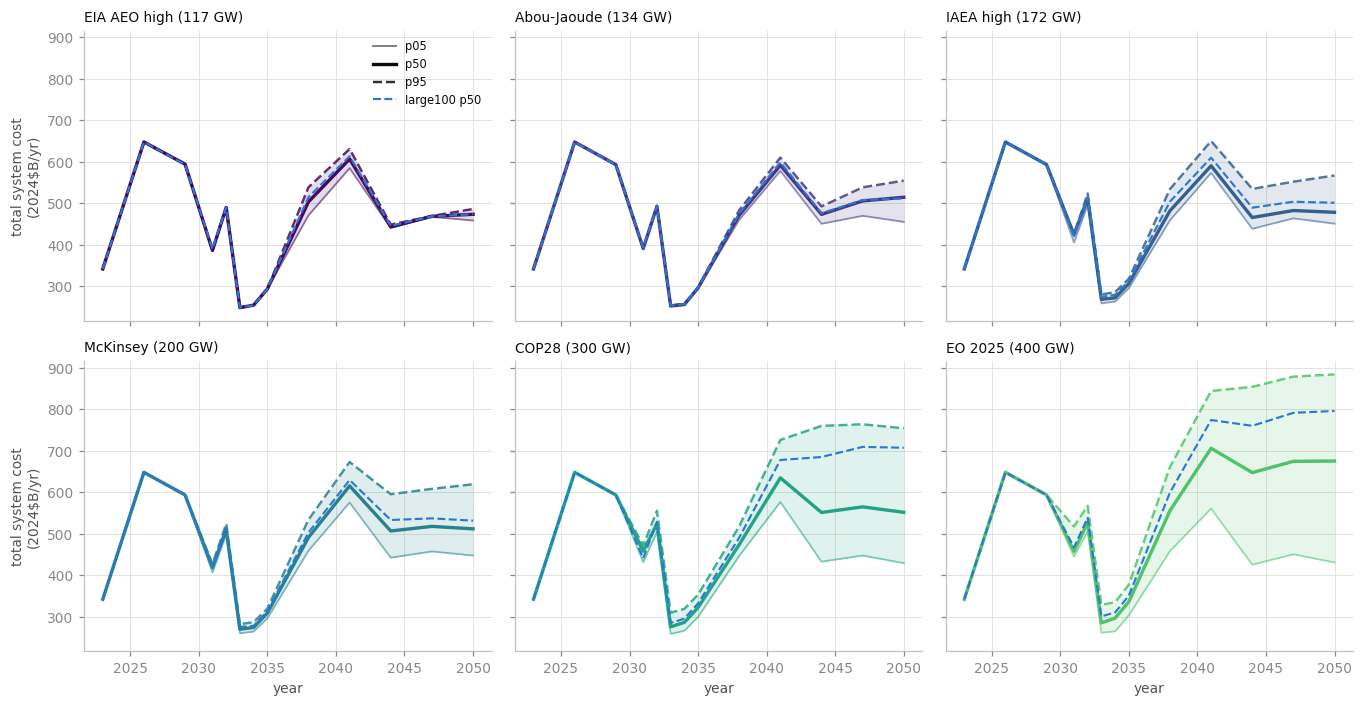

In [22]:
# ---- f09: total annual system cost fans -----------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.5), sharex=True, sharey=True)
for k, s in enumerate(SCHEDULES):
    ax = axes.flat[k]
    piv = {p: CTOT.loc[f"smr100_{s}_{p}"] for p in ("p05", "p50", "p95")}
    yrs = [t for t in YEARS_RUN if t >= 2023]
    ax.fill_between(yrs, piv["p05"][yrs], piv["p95"][yrs], color=SCHED_C[s],
                    alpha=0.14, lw=0)
    for p in ("p05", "p50", "p95"):
        ax.plot(yrs, piv[p][yrs], color=SCHED_C[s], **PCT_STYLE[p])
    lg = CTOT.loc[f"large100_{s}_p50"]
    ax.plot(yrs, lg[yrs], color=COL["large"], lw=1.4, ls="--")
    ax.set_title(SCHED_LABEL[s], fontsize=9)
    if k % 3 == 0:
        ax.set_ylabel("total system cost\n(2024$B/yr)")
    if k >= 3:
        ax.set_xlabel("year")
axes.flat[0].legend([mpl.lines.Line2D([], [], color=INK, **PCT_STYLE[p])
                     for p in ("p05", "p50", "p95")]
                    + [mpl.lines.Line2D([], [], color=COL["large"], lw=1.4, ls="--")],
                    ["p05", "p50", "p95", "large100 p50"], fontsize=7.5)
fig.tight_layout()
savefig(fig, "f09_cost_totals.png")
plt.show()


saved -> figures\f10_within_schedule_spread.png


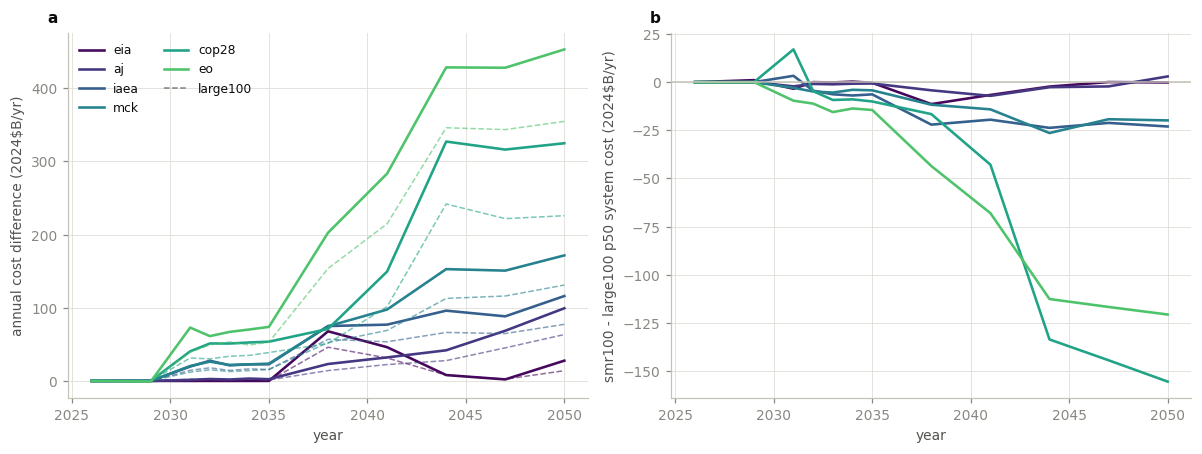

schedule    t  p95_minus_p05_B2024  large_p95_minus_p05_B2024  smr_minus_large_p50_B2024
     eia 2050                27.71                      14.04                      -0.16
      aj 2050                99.34                      63.43                       2.97
    iaea 2050               116.05                      77.37                     -23.04
     mck 2050               171.57                     131.01                     -19.88
   cop28 2050               324.80                     225.82                    -155.55
      eo 2050               453.01                     354.69                    -120.71


In [23]:
# ---- f10 + t06: the two clean cost comparisons ----------------------------------------------
yrs = [t for t in YEARS_RUN if t >= 2026]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
rows = []
for s in SCHEDULES:
    spread = CTOT.loc[f"smr100_{s}_p95"] - CTOT.loc[f"smr100_{s}_p05"]
    spread_l = CTOT.loc[f"large100_{s}_p95"] - CTOT.loc[f"large100_{s}_p05"]
    delta = CTOT.loc[f"smr100_{s}_p50"] - CTOT.loc[f"large100_{s}_p50"]
    axes[0].plot(yrs, spread[yrs], color=SCHED_C[s], lw=1.7, label=s)
    axes[0].plot(yrs, spread_l[yrs], color=SCHED_C[s], lw=1.0, ls="--", alpha=0.6)
    axes[1].plot(yrs, delta[yrs], color=SCHED_C[s], lw=1.7)
    for t in yrs:
        rows.append(dict(schedule=s, t=t,
                         p95_minus_p05_B2024=round(float(spread[t]), 2),
                         large_p95_minus_p05_B2024=round(float(spread_l[t]), 2),
                         smr_minus_large_p50_B2024=round(float(delta[t]), 2)))
axes[0].set_ylabel("annual cost difference (2024$B/yr)")
h10, l10 = axes[0].get_legend_handles_labels()
axes[0].legend(h10 + [mpl.lines.Line2D([], [], color=MUTED, lw=1.0, ls="--",
                                       alpha=0.7)],
               l10 + ["large100"], fontsize=8, ncols=2)
axes[1].axhline(0, color=EDGE_C, lw=1)
axes[1].set_ylabel("smr100 - large100 p50 system cost (2024$B/yr)")
ps.letter_panels(axes)
for ax in axes:
    ax.set_xlabel("year")
fig.tight_layout()
savefig(fig, "f10_within_schedule_spread.png")
plt.show()
t06 = pd.DataFrame(rows)
t06.to_csv(EXPORTS / "t06_cost_deltas.csv", index=False)
print(t06[t06["t"] == 2050].to_string(index=False))


## S7 — System NPV

**Convention (chosen 2026-08-12).** The NPV is the sum of the total annual
`systemcost` over the calendar years 2026-2050, discounted at the ReEDS system
real rate:

NPV = sum over y in [2026, 2050] of C(m(y)) / DR^(y - 2026)

where C(t) is the total annual system cost in the solve year t, m(y) maps the
calendar year y to the solve year that represents it (solve year t covers the
years from t to the next solve year minus one), and DR is the mean ReEDS system
real discount rate. Results show in billion dollars of 2024.

**Why not the objective.** In the sequential solve, `z_rep` and `objfn_raw`
mix lump investment with operations weighted over a 20-year window per solve.
A sum of them double-counts operations. The annual `systemcost` streams with
explicit discounting are transparent, and they match the discounting of the
dual PV in section S8.

**End-effect caveat.** Investment enters as a lump in the build year, and the
window stops at 2050. Late mandated builds carry full capex but show none of
their post-2050 service value. This penalizes the ambitious schedules. Keep
this in mind before any cross-schedule reading; the conflation caveat applies
on top.

*Figure note (f11): system NPV against schedule ambition; levels mix mandate and drawn world, and end effects penalize late builds. Orange circles = smr100, blue squares (dashed) = large100.*

system NPV, 2026-2050, mean real rate, 2024 $B:
schedule  ambition_2050_GW  smr_p05  smr_p50  smr_p95  large_p05  large_p50  large_p95  p95_minus_p05  smr_minus_large_p50
     eia             117.3   7395.3   7493.1   7600.0     7459.0     7526.6     7602.0          204.7                -33.5
      aj             134.0   7390.9   7523.7   7654.4     7476.6     7551.5     7651.8          263.5                -27.8
    iaea             172.3   7384.6   7576.2   7999.7     7557.7     7726.9     7994.8          615.1               -150.7
     mck             200.0   7386.6   7730.5   8195.9     7618.2     7854.7     8200.6          809.3               -124.2
   cop28             300.0   7369.6   7935.1   8847.9     7857.1     8436.8     8904.3         1478.3               -501.8
      eo             400.0   7382.1   8510.3   9674.4     8071.5     9067.2     9845.7         2292.3               -556.8


saved -> figures\f11_npv_vs_ambition.png


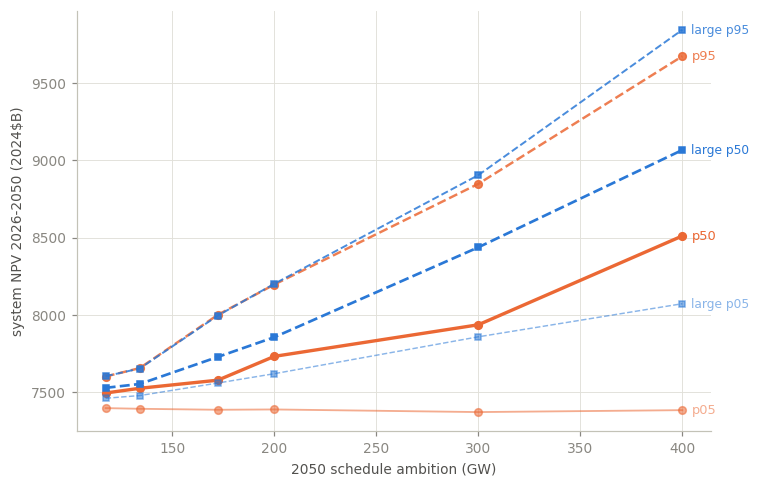

In [24]:
# ---- t07 + f11: system NPV -------------------------------------------------------------------
POST = [t for t in YEARS_RUN if t >= 2026]

def year_rep(y):
    return max(t for t in POST if t <= y)

def npv_of(series_by_t):
    return sum(float(series_by_t[year_rep(y)]) / DR ** (y - 2026)
               for y in range(2026, 2051))

NPV = {c: npv_of(CTOT.loc[c]) for c in CASES}      # 2024 $B
rows = []
for s in SCHEDULES:
    rows.append(dict(
        schedule=s, ambition_2050_GW=SCHED_GW[s],
        smr_p05=round(NPV[f"smr100_{s}_p05"], 1),
        smr_p50=round(NPV[f"smr100_{s}_p50"], 1),
        smr_p95=round(NPV[f"smr100_{s}_p95"], 1),
        large_p05=round(NPV[f"large100_{s}_p05"], 1),
        large_p50=round(NPV[f"large100_{s}_p50"], 1),
        large_p95=round(NPV[f"large100_{s}_p95"], 1),
        p95_minus_p05=round(NPV[f"smr100_{s}_p95"] - NPV[f"smr100_{s}_p05"], 1),
        smr_minus_large_p50=round(NPV[f"smr100_{s}_p50"] - NPV[f"large100_{s}_p50"], 1),
    ))
t07 = pd.DataFrame(rows)
t07.to_csv(EXPORTS / "t07_system_npv.csv", index=False)
print("system NPV, 2026-2050, mean real rate, 2024 $B:")
print(t07.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4.5))
xs = [SCHED_GW[s] for s in SCHEDULES]
for p in ("p05", "p50", "p95"):
    ys = [NPV[f"smr100_{s}_{p}"] for s in SCHEDULES]
    ax.plot(xs, ys, marker="o", ms=5, color=COL["smr"], **PCT_STYLE[p])
    ax.annotate(p, (xs[-1], ys[-1]), xytext=(6, 0), textcoords="offset points",
                color=COL["smr"], alpha=PCT_STYLE[p]["alpha"], fontsize=8.5, va="center")
for p in ("p05", "p50", "p95"):
    ys_l = [NPV[f"large100_{s}_{p}"] for s in SCHEDULES]
    ax.plot(xs, ys_l, marker="s", ms=4, color=COL["large"], ls="--",
            lw=PCT_STYLE[p]["lw"] * 0.8, alpha=PCT_STYLE[p]["alpha"])
    ax.annotate(f"large {p}", (xs[-1], ys_l[-1]), xytext=(6, 0),
                textcoords="offset points", color=COL["large"], fontsize=8,
                va="center", alpha=PCT_STYLE[p]["alpha"])
ax.set_xlabel("2050 schedule ambition (GW)")
ax.set_ylabel("system NPV 2026-2050 (2024$B)")
fig.tight_layout()
savefig(fig, "f11_npv_vs_ambition.png")
plt.show()


## S8 — Rental transfer, ITC translation, and the instrument menu

This section follows the procedure in `ITC calculation procedure.md` (this
folder). The solve is sequential. Each year's LP prices its own builds fully.
Because of this, the ITC translation does not discount across years.

The compliance-market reading of the mandate is a **capacity standard with
tradable capacity credits**: the constraint is written on MW standing, and
the dual is the capacity-credit clearing price. (An RPS/REC is the per-MWh
cousin, not the analog.)

The section builds three fiscal exhibits. Their names stay separate:

- **Rental transfer** R_t = dual(t) x program capacity(t): the by-year bill
  of the capacity standard. Its PV discounts each solve year over its forward
  gap (years to the next solve year; the terminal 2050 gap is 1). t17
  restates the same bill per vintage to remove the 2050 truncation.
- **ITC outlay** B_t = i_model(t) x ccmult(t) x capex base of all builds in
  year t: the credit's face value accrued to commissioning. It appears after
  the rate calculation below.
- **The instrument menu** (t18): every instrument's net-of-tax PV cost as a
  multiple of the minimum-cost floor, with the commitment bound below the
  floor and the commitment ITC (t19) as its rate schedule.

The rental transfer pays inframarginal capacity as well as the marginal unit.
That is a property of uniform instruments, not a bug.

*Figure note (f12): the rental transfer R_t = dual × mandated capacity — panel a: R_t fans per schedule (smr100 solid with p05–p95 band, large100 dashed); panel b: PV of R_t over 2026–2050, per case.*

              case  PV_rental_transfer_2024B  peak_Rt_2024B  peak_Rt_year
    smr100_eia_p05                       5.6            1.7          2038
    smr100_eia_p50                      31.1            6.4          2050
    smr100_eia_p95                      56.7           12.0          2050
     smr100_aj_p05                       9.5            2.5          2050
     smr100_aj_p50                      32.7           13.4          2050
     smr100_aj_p95                      58.4           22.8          2050
   smr100_iaea_p05                      23.6            4.5          2050
   smr100_iaea_p50                      91.8           17.5          2050
   smr100_iaea_p95                     204.8           47.0          2050
    smr100_mck_p05                      24.3            4.3          2050
    smr100_mck_p50                     116.3           27.7          2050
    smr100_mck_p95                     237.4           62.6          2050
  smr100_cop28_p05                    

saved -> figures\f12_rental_transfer.png


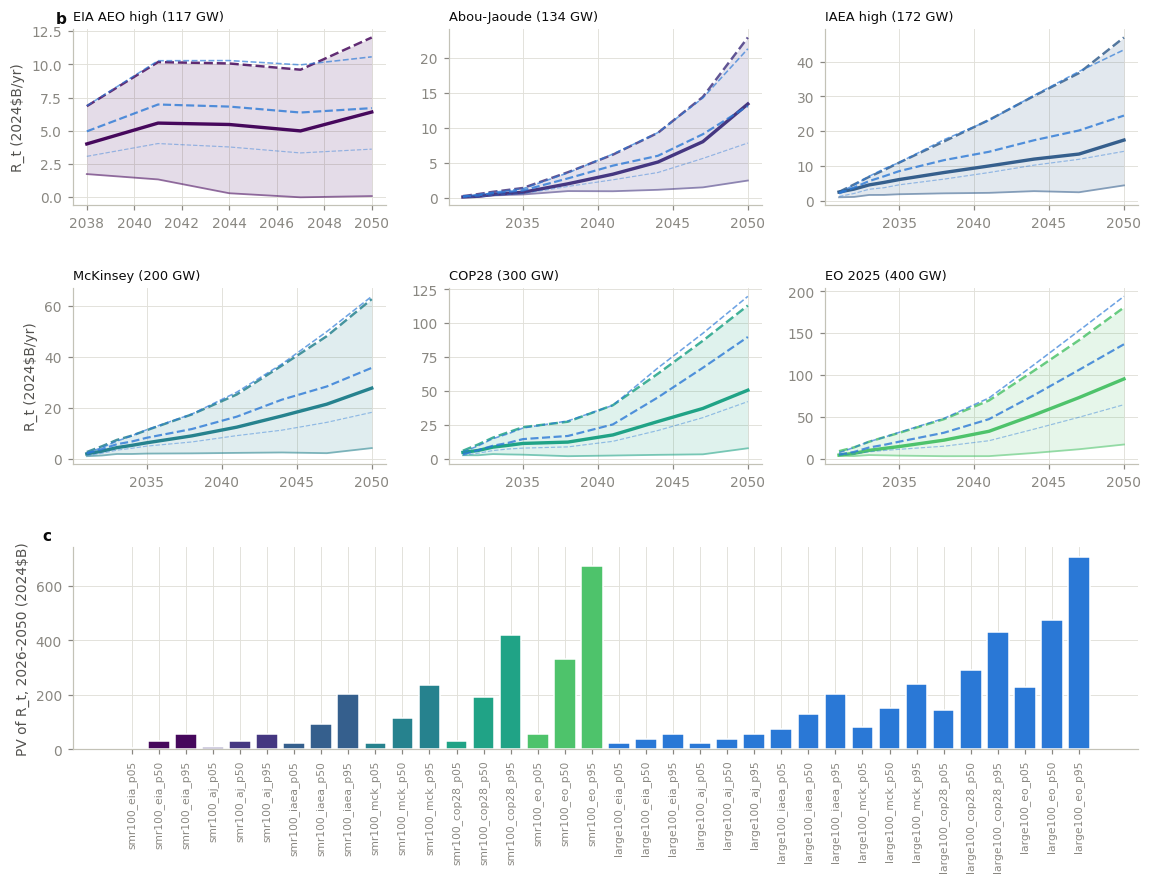

In [25]:
# ---- t08 + f12: rental transfer R_t ------------------------------------------------------------
GAP = {t: (YEARS_RUN[i + 1] - t if i + 1 < len(YEARS_RUN) else 1)
       for i, t in enumerate(YEARS_RUN)}

BILL = {}      # per case: R_t Series over solve years, 2024 $B / yr
rows = []
for c in CASES:
    d = DUALS[(DUALS["case"] == c) & (DUALS["t"] >= 2026)].set_index("t").sort_index()
    # R_t pays the dual on the program's post-2030 additions; the old
    # mandate_MW basis also billed the pre-existing ~97 GW fleet that the
    # fleet-inclusive large100 mandate counts (fixed 2026-08-17). No-build
    # years are blank, not zero.
    bill = (d["dual_2004_MWyr"] * d["program_MW"] * TO2024
            / 1e9).where(d["program_MW"] > 0)
    BILL[c] = bill
    pv = sum(float(bill[t]) * GAP[t] / DR ** (t - 2026)
             for t in bill.dropna().index)
    rows.append(dict(case=c, PV_rental_transfer_2024B=round(pv, 1),
                     peak_Rt_2024B=round(float(bill.max()), 1),
                     peak_Rt_year=int(bill.idxmax()) if bill.max() > 0 else None))
t08 = pd.DataFrame(rows)
t08.to_csv(EXPORTS / "t08_rental_transfer.csv", index=False)
print(t08.to_string(index=False))

fig = plt.figure(figsize=(12.5, 8.5))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.15], hspace=0.45)
for k, s in enumerate(SCHEDULES):
    ax = fig.add_subplot(gs[k // 3, k % 3])
    yrs = [t for t in YEARS_RUN if t >= 2029]
    lo, hi = BILL[f"smr100_{s}_p05"], BILL[f"smr100_{s}_p95"]
    ax.fill_between(yrs, lo.reindex(yrs), hi.reindex(yrs), color=SCHED_C[s],
                    alpha=0.14, lw=0)
    for p in ("p05", "p50", "p95"):
        b = BILL[f"smr100_{s}_{p}"]
        ax.plot(yrs, b.reindex(yrs), color=SCHED_C[s], **PCT_STYLE[p])
    for p in ("p05", "p50", "p95"):
        bl = BILL[f"large100_{s}_{p}"]
        ax.plot(yrs, bl.reindex(yrs), color=COL["large"], ls="--",
                lw=PCT_STYLE[p]["lw"] * 0.65, alpha=PCT_STYLE[p]["alpha"] * 0.8)
    ax.set_title(SCHED_LABEL[s], fontsize=8.5)
    if k % 3 == 0:
        ax.set_ylabel("R_t (2024$B/yr)")
axb = fig.add_subplot(gs[2, :])
order = ([f"smr100_{s}_{p}" for s in SCHEDULES for p in ("p05", "p50", "p95")]
         + [f"large100_{s}_{p}" for s in SCHEDULES for p in ("p05", "p50", "p95")])
pvv = t08.set_index("case")["PV_rental_transfer_2024B"].reindex(order)
cols = [SCHED_C[parse_case(c)[1]] if parse_case(c)[0] == "smr" else COL["large"]
        for c in order]
axb.bar(range(len(order)), pvv.values, color=cols, edgecolor=SURFACE)
axb.set_xticks(range(len(order)), order, rotation=90, fontsize=7)
axb.set_ylabel("PV of R_t, 2026-2050 (2024$B)")
# continuation letters: composed Fig4 stamps "a" on the required-ITC grid
ps.panel_letter(fig.axes[0], "b")
ps.panel_letter(axb, "c")
savefig(fig, "f12_rental_transfer.png")
plt.show()


### ITC translation for a sequential run

The translation follows `ITC calculation procedure.md`. Convention revised
2026-08-18 (supersedes the 2026-08-14 statutory-timing lock): the headline is
the model-convention rate i_model, and every instrument in this section is
priced inside ReEDS's own financing arithmetic.

The logic: each yearly LP is the full decision problem for its builds. The raw
dual of the floor constraint is the capitalized gap of the marginal build in
that solve. Thus the subsidy for a build in year t is:

S_t = raw dual(t) / cost_scale = converted dual(t) x pvf_onm(t)

S_t is in 2004 dollars per MW. It contains capital cost, fixed O&M, and
variable costs, minus the market value of the build. No discounting across
years applies, because the year-t solve prices the build fully.

A year enters the ITC schedule only if three conditions hold: the dual is
positive, the mandate increases in that year, and the model builds new
mandated capacity in that year (`cap_new_ann` > 0). Slack years get a zero
required ITC and stay in the table as results.

The rate calculation inverts the ReEDS financing arithmetic
(`reeds/financials.py`, lines 683-694). fin_mult is a linear function of the
monetized fraction m. The per-region solution is:

m_t(r) = S_t / (cost_cap(t) x fin_mult_noITC(r, t)) x k(t)

with k(t) = (1 - tax x PV_dep) / (1 - tax x PV_dep / 2). k is below 1: one
dollar of credit gives more than one dollar of support, because of the tax
grossup, less the half-basis depreciation reduction.

The headline rate applies one correction to m:

i_model(r) = m_t(r) / (1 - itc_tax_equity_penalty)

The penalty (0.1, from the OBBBA incentives input) covers the monetization
haircut.

The credit convention, stated mechanism-agnostically: in the fin_mult formula
the credit fraction and the half-basis clawback both apply to the invested
basis OCC x ccmult, so a credit dollar carries construction-period carrying
cost. At least two real designs deliver exactly this value to the developer:
(i) a progress payment during construction (the old Section 46 QPE design),
and (ii) a placed-in-service claim on the interest-inclusive Section 263A
basis - the literal reading of the formula. Payment timing is PV-neutral
here: ccmult accrues at interest_rate_nom = 8.0% nominal, and the ledger's
after-tax nominal WACC is 7.99%, so the two mechanisms also cost the
government the same present value. The convention does not assume how the
credit is paid; it fixes what a credit dollar is worth.

Conversion for readers: a placed-in-service credit written on an
overnight-cost-only basis must be ccmult(t) times larger; the table carries
that companion as the i_pis_* columns. Under Section 263A(f), capitalized
construction interest (debt interest actually paid) enters the eligible
basis, so the true statutory rate for a given owner lies between i_model and
i_model x ccmult. That placement is a legal fact about the owner, not a
modeling choice; readers convert with the exported ccmult column.

The run does not identify the marginal region (result P7). The table reports
the rate range over the regions that build. The headline rate is the maximum
of the range. The maximum is enough for the last mandated MW. If the required
rate is above 100%, an ITC alone cannot supply S_t; an operating subsidy must
supply the remainder. The table flags those years.

The 48E band in the figure is 30% (base) to 50% (base plus bonuses); rates on
different conventions are compared with law only after the reader's own basis
conversion.

*Figure note (f13): required ITC rate (model convention) per solve year, smr100.*

In [26]:
# ---- financing replication: natbase, PV_dep, k (procedure steps 5-6) ---------------------------
# Ported from z-ethan/pilots/_build_notebook.py (P4, QA-verified machinery).
DEP = pd.read_csv(FIN_DIR / "depreciation_schedules_default.csv")
CS = pd.read_csv(FIN_DIR / "construction_schedules_mc.csv")
# row-aligned ReEDS exponents: header 'NA' row -> 0, rows t=0..9 -> 0.5..9.5
CC_EXPS = np.append([0.0], np.arange(0.5, 10.5, 1.0))
assert len(CS) == len(CC_EXPS), (len(CS), len(CC_EXPS))

def ccmult_reeds(sched_name, ib):
    x = pd.to_numeric(CS[str(sched_name)], errors="coerce").fillna(0.0).to_numpy()
    return 1.0 + float(np.sum(x * (ib ** CC_EXPS - 1.0)))

IN_NAME = {"nuclear": "Nuclear", "nuclear-smr": "Nuclear-SMR"}

def fin_tech(case):
    fin = sw(case, "financials_tech_suffix")
    ft = pd.read_csv(FIN_DIR / f"financials_tech_{fin}.csv")
    ft.columns = [c.lstrip("*") for c in ft.columns]
    return ft[ft["i"].isin(["Nuclear", "Nuclear-SMR"])]

_NF_CACHE = {}

def natfin(case):
    """(natbase, k, ccm) Series triples on YEARS for the case's mandated technology.
    natbase = ccmult / (1 - tax) x (1 - tax x PV_dep) x risk x eval_adj — the
    r-independent part of cost_cap_fin_mult_noITC (Degradation_Adj = 1 for nuclear).
    k = (1 - tax x PV_dep) / (1 - tax x PV_dep / 2) converts the financed-cost
    ratio S / (cost_cap x fin_mult_noITC) to the monetized fraction m.
    ccm is the construction-financing multiplier; the statutory timing
    correction multiplies the rate by it."""
    key = (case, META[case]["mandated_tech"])
    if key in _NF_CACHE:
        return _NF_CACHE[key]
    grp = fin_tech(case)
    grp = grp[grp["i"] == IN_NAME[META[case]["mandated_tech"]]]
    grp = grp.set_index("t").reindex(YEARS).ffill().bfill()
    dep_col = str(int(grp["depreciation_sch"].iloc[0]))
    dep_frac = pd.to_numeric(DEP[dep_col], errors="coerce").fillna(0.0).to_numpy(float)
    pv_dep = np.array([np.sum(dep_frac / dn ** np.arange(1, len(dep_frac) + 1))
                       for dn in D_NOM])
    eval_p = float(grp["eval_period"].iloc[0])
    risk = 1.0 + grp["finance_diff_real"].to_numpy(float) * (
        (1 - (1 / D_REAL) ** eval_p) / (D_REAL - 1.0))
    sys_pvf = (1 - (1 / D_REAL) ** (30 - 1)) / (D_REAL - 1.0) + 1
    tech_pvf = (1 - (1 / D_REAL) ** (eval_p - 1)) / (D_REAL - 1.0) + 1
    eval_adj = sys_pvf / tech_pvf
    ccm = np.array([ccmult_reeds(grp.loc[t, "construction_sch"], IB[yi(t)])
                    for t in YEARS])
    natbase = pd.Series(ccm / (1 - TAX) * (1 - TAX * pv_dep) * risk * eval_adj,
                        index=YEARS)
    k = pd.Series((1 - TAX * pv_dep) / (1 - TAX * pv_dep / 2), index=YEARS)
    ccm = pd.Series(ccm, index=YEARS)
    _NF_CACHE[key] = (natbase, k, ccm)
    return natbase, k, ccm

# self-check: natbase x a time-constant regional factor reproduces the h5 multiplier.
# The time dimension makes this non-circular: it tests the time shape of natbase.
for c in ["smr100_eia_p50", "smr100_eo_p95", "large100_eo_p50", "large100_eo_p95"]:
    nb, _, _ = natfin(c)
    piv = FINMULT[c].unstack("t")
    yrs = [t for t in piv.columns if t >= 2026]
    ratio = piv[yrs].div(nb.reindex(yrs), axis=1)
    regfac = ratio.mean(axis=1)
    resid = (piv[yrs] - pd.DataFrame(np.outer(regfac, nb.reindex(yrs)),
                                     index=piv.index, columns=yrs)).abs() / piv[yrs]
    worst = float(resid.max().max())
    assert worst < 5e-3, (c, worst)
    assert 0.85 < float(regfac.min()) and float(regfac.max()) < 1.35, c
    print(f"{c}: natbase reproduces the h5 multiplier; worst rel resid {worst:.1e}; "
          f"regional factors {float(regfac.min()):.3f}..{float(regfac.max()):.3f}")


smr100_eia_p50: natbase reproduces the h5 multiplier; worst rel resid 5.9e-04; regional factors 0.953..1.254
smr100_eo_p95: natbase reproduces the h5 multiplier; worst rel resid 5.2e-04; regional factors 0.953..1.254
large100_eo_p50: natbase reproduces the h5 multiplier; worst rel resid 5.4e-04; regional factors 0.953..1.254
large100_eo_p95: natbase reproduces the h5 multiplier; worst rel resid 5.1e-04; regional factors 0.953..1.254


In [27]:
# ---- procedure step 1: baseline checks ----------------------------------------------------------
inc_no = pd.read_csv(FIN_DIR / "incentives_obbba_nonuclearitc.csv")
nuc_no = inc_no[inc_no["i"].str.upper().str.startswith("NUCLEAR")]
itc_cols = [c for c in inc_no.columns if c.startswith("itc_")]
assert float(nuc_no[itc_cols].abs().to_numpy().sum()) == 0.0, "input file has nuclear ITC"
worst_fm = max(FMDIFF.values())
assert worst_fm < 1e-9, f"fin_mult != fin_mult_noITC somewhere: {worst_fm}"
print("baseline holds: zero nuclear ITC in the incentives input; "
      "fin_mult == fin_mult_noITC for the mandated technology in all 37 runs.")
print("Thus the dual is the total required support, not an increment.")

# statutory conversion uses the OBBBA penalty for a hypothetical nuclear credit
inc_ob = pd.read_csv(FIN_DIR / "incentives_obbba.csv")
nuc_ob = inc_ob[inc_ob["i"].str.upper().str.startswith("NUCLEAR")]
PEN = float(nuc_ob["itc_tax_equity_penalty"].iloc[0])
assert (nuc_ob["itc_tax_equity_penalty"] == PEN).all()
print(f"itc_tax_equity_penalty = {PEN}; statutory i = m / (1 - {PEN})")


baseline holds: zero nuclear ITC in the incentives input; fin_mult == fin_mult_noITC for the mandated technology in all 37 runs.
Thus the dual is the total required support, not an increment.
itc_tax_equity_penalty = 0.1; statutory i = m / (1 - 0.1)


In [28]:
# ---- t09: required ITC rates per the procedure ---------------------------------------------------
TPREV = {t: (YEARS_RUN[i - 1] if i > 0 else None) for i, t in enumerate(YEARS_RUN)}
rate_rows = []
for c in CASES:
    tech = META[c]["mandated_tech"]
    nb, K, CCM = natfin(c)
    d = DUALS[DUALS["case"] == c].set_index("t").sort_index()
    cc, fm, bl, tr = COSTCAP[c], FINMULT[c], CAPNEW[c], TRAJ[c]
    for t in YEARS_RUN:
        if not bool(d.loc[t, "mandated"]):
            continue
        dual_pos = bool(d.loc[t, "binding"])
        m_inc = float(tr.get(t, 0.0)) - float(tr.get(TPREV[t], 0.0) if TPREV[t] else 0.0)
        blt = bl.xs(t, level="t") if t in bl.index.get_level_values("t") else pd.Series(dtype=float)
        blt = blt[blt > 0]
        if not dual_pos:
            status = "slack: required ITC is zero"
        elif m_inc <= 0:
            status = "no mandate increase: no build receives a credit"
        elif not len(blt):
            status = "no new builds: dual prices retention, not a build"
        else:
            status = "rate"
        row = dict(case=c, t=t, status=status, S_t_2004_per_MW=None, n_build_regions=0,
                   ccmult=None, i_model_min=None, i_model_max=None,
                   i_model_headline=None, i_pis_min=None, i_pis_max=None,
                   i_pis_headline=None, S_x_2p2GW_2024B=None,
                   itc_insufficient=False, pis_insufficient=False)
        if status == "rate":
            S = float(d.loc[t, "dual_raw"])                       # cost_scale = 1
            S_alt = float(d.loc[t, "dual_2004_MWyr"]) * float(PVF[c].loc[t])
            assert abs(S - S_alt) <= 1e-4 * max(1.0, abs(S)), (c, t, S, S_alt)
            fmb = fm.xs(t, level="t").reindex(blt.index).dropna()
            m_r = S / (float(cc.loc[t]) * fmb) * float(K.loc[t])  # monetized, per region
            i_r = m_r / (1.0 - PEN)   # the headline: ReEDS's credit convention
            ccm_t = float(CCM.loc[t])
            # conversion companion: placed-in-service credit on an OCC-only basis
            i_pis = i_r * ccm_t
            row.update(S_t_2004_per_MW=round(S), n_build_regions=len(i_r),
                       ccmult=round(ccm_t, 4),
                       i_model_min=round(float(i_r.min()), 3),
                       i_model_max=round(float(i_r.max()), 3),
                       i_model_headline=round(float(i_r.max()), 3),
                       i_pis_min=round(float(i_pis.min()), 3),
                       i_pis_max=round(float(i_pis.max()), 3),
                       i_pis_headline=round(float(i_pis.max()), 3),
                       # marginal-build gap on one Vogtle-pair-equivalent (2.2 GW)
                       S_x_2p2GW_2024B=round(S * 2200.0 * TO2024 / 1e9, 1),
                       itc_insufficient=bool(i_r.max() > 1.0),
                       pis_insufficient=bool(i_pis.max() > 1.0))
        rate_rows.append(row)
t09 = pd.DataFrame(rate_rows)
t09.to_csv(EXPORTS / "t09_required_itc.csv", index=False)
n_over = int(t09["itc_insufficient"].sum())
print(f"gated (case, year) points: {len(t09)}; rate rows: "
      f"{int((t09['status'] == 'rate').sum())}; model-convention rate above 100%: {n_over}")
ne9 = t09[~t09["case"].str.endswith("_eq")]     # the eq copy duplicates one world
print(f"excluding the equality duplicate: rate rows "
      f"{int((ne9['status'] == 'rate').sum())}; "
      f"above 100%: {int(ne9['itc_insufficient'].sum())} "
      f"(pis conversion: {int(ne9['pis_insufficient'].sum())})")
s9 = ne9[ne9["case"].str.startswith("smr100") & (ne9["status"] == "rate")]
print(f"smr100 only: rate rows {len(s9)}; "
      f"above 100%: {int(s9['itc_insufficient'].sum())}")
print("\nrequired ITC rate (model convention), smr100 p50:")
p50 = t09[(t09["case"].isin([f"smr100_{s}_p50" for s in SCHEDULES]))
          & (t09["status"] == "rate")]
print(p50.pivot_table(index="t", columns="case", values="i_model_headline").round(2).to_string())
print("\nconversion companion (placed-in-service, OCC-only basis), same cases:")
print(p50.pivot_table(index="t", columns="case", values="i_pis_headline").round(2).to_string())
print("\nexcluded mandated years by reason:")
print(t09[t09["status"] != "rate"].groupby("status").size().to_string())


gated (case, year) points: 386; rate rows: 334; model-convention rate above 100%: 6
excluding the equality duplicate: rate rows 329; above 100%: 6 (pis conversion: 82)
smr100 only: rate rows 164; above 100%: 3

required ITC rate (model convention), smr100 p50:
case  smr100_aj_p50  smr100_cop28_p50  smr100_eia_p50  smr100_eo_p50  smr100_iaea_p50  smr100_mck_p50
t                                                                                                    
2031           0.62              0.84             NaN           0.70             0.84            0.76
2032           0.41              0.72             NaN           0.59             0.76            0.68
2033           0.70              0.78             NaN           0.68             0.79            0.73
2034           0.65              0.73             NaN           0.65             0.75            0.69
2035           0.63              0.70             NaN           0.63             0.70            0.69
2038           0.66      

saved -> figures\f13_required_itc.png


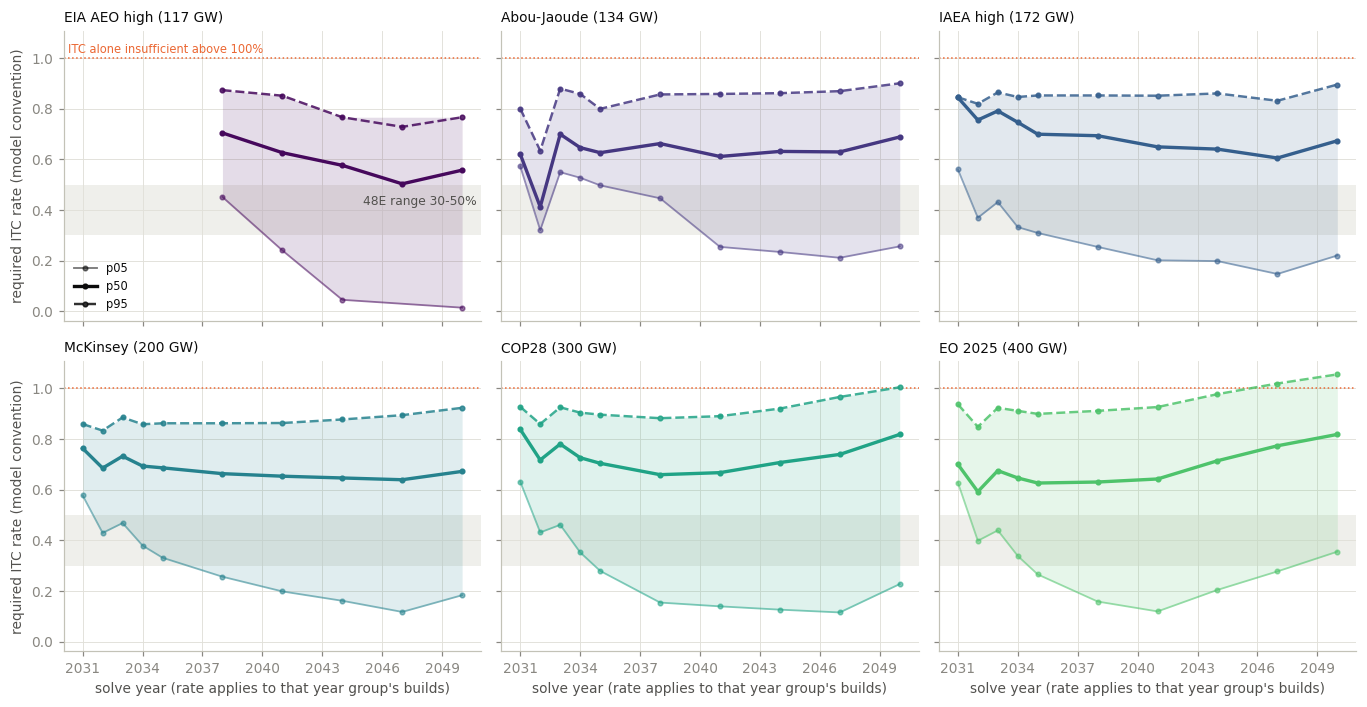

mean p50 rate as a multiple of the 30% base 48E credit: {'eia': 2.0, 'aj': 2.1, 'iaea': 2.4, 'mck': 2.3, 'cop28': 2.5, 'eo': 2.3}
same multiple in the p95 (expensive) worlds, equal prominence: {'eia': 2.7, 'aj': 2.8, 'iaea': 2.8, 'mck': 2.9, 'cop28': 3.1, 'eo': 3.1}


In [29]:
# ---- f13: required ITC rate (model convention) against solve year ------------------------------------------
t09i = t09[t09["status"] == "rate"].set_index(["case", "t"])["i_model_headline"]

def _rate(case):
    """Per-year rate series for one case; empty if no year of that case reached 'rate' status."""
    if case in t09i.index.get_level_values("case"):
        return t09i.loc[case].sort_index()
    return pd.Series(dtype=float)

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.5), sharex=True, sharey=True)
mult = {}
for k, s in enumerate(SCHEDULES):
    ax = axes.flat[k]
    ax.axhspan(0.30, 0.50, color=GRID_C, alpha=0.5, lw=0, zorder=0)
    ax.axhline(1.0, color=COL["smr"], lw=1.0, ls=":")
    r = {p: _rate(f"smr100_{s}_{p}") for p in ("p05", "p50", "p95")}
    band = sorted(set(r["p05"].index) & set(r["p95"].index))
    if band:
        ax.fill_between(band, r["p05"][band], r["p95"][band], color=SCHED_C[s],
                        alpha=0.14, lw=0)
    for p in ("p05", "p50", "p95"):
        if not r[p].empty:
            ax.plot(r[p].index, r[p].values, color=SCHED_C[s], marker="o", ms=3.0,
                    **PCT_STYLE[p])
    ax.set_title(SCHED_LABEL[s], fontsize=9)
    if k % 3 == 0:
        ax.set_ylabel("required ITC rate (model convention)")
    if k >= 3:
        ax.set_xlabel("solve year (rate applies to that year group's builds)")
    mult[s] = round(float(r["p50"].mean()) / 0.30, 1)
ax0 = axes.flat[0]
ax0.text(0.99, 0.42, "48E range 30-50%", fontsize=8, color=MUTED,
         ha="right", transform=ax0.get_yaxis_transform())
ax0.text(0.01, 1.01, "ITC alone insufficient above 100%", fontsize=7.5, color=COL["smr"],
         ha="left", va="bottom", transform=ax0.get_yaxis_transform())
ax0.legend([mpl.lines.Line2D([], [], color=INK, marker="o", ms=3.0, **PCT_STYLE[p])
            for p in ("p05", "p50", "p95")],
           ["p05", "p50", "p95"], fontsize=7.5)
ax0.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
fig.tight_layout()
savefig(fig, "f13_required_itc.png")
plt.show()
print("mean p50 rate as a multiple of the 30% base 48E credit:", mult)
p95m = {s: round(float(t09i.loc[f'smr100_{s}_p95'].mean()) / 0.30, 1) for s in SCHEDULES}
print("same multiple in the p95 (expensive) worlds, equal prominence:", p95m)

### t16 - BOC rate-lock windfall

Where the required-rate schedule declines, a beginning-of-construction (BOC)
rate lock pays a 6-year build the spread between the locked rate and the
placed-in-service-year rate. t16 quantifies that spread over every 6-year
span of every case's rate schedule (annual, linearly interpolated between
solve years), with the declining-segment conditioning explicit: rates rise
into the late horizon in most p50 worlds, where the same lock is a shortfall,
not a windfall.

In [30]:
# ---- t16: BOC 6-year rate-lock windfall over declining rate segments -----------------
wrows = []
for c in sorted(t09["case"].unique()):
    if c.endswith("_eq"):
        continue
    sub = (t09[(t09["case"] == c) & (t09["status"] == "rate")]
           .set_index("t")["i_model_headline"])
    if len(sub) < 2:
        continue
    yrs = list(range(int(sub.index.min()), int(sub.index.max()) + 1))
    ann = sub.reindex(yrs).interpolate(method="index")
    for y in yrs:
        if y + 6 > yrs[-1]:
            break
        w = float(ann.loc[y] - ann.loc[y + 6])
        wrows.append(dict(case=c, boc_year=y, windfall_pts=round(w * 100, 1),
                          declining=bool(w > 0)))
t16 = pd.DataFrame(wrows)
t16.to_csv(EXPORTS / "t16_boc_windfall.csv", index=False)
w50 = t16[t16["case"].str.startswith("smr100") & t16["case"].str.endswith("_p50")]
d50 = w50[w50["declining"]]["windfall_pts"]
print(f"smr100 p50, declining 6-year spans: n={len(d50)} of {len(w50)} "
      f"({w50['declining'].mean():.0%}); windfall median {d50.median():.1f} pts, "
      f"IQR {d50.quantile(0.25):.1f}-{d50.quantile(0.75):.1f}, max {d50.max():.1f}")
ref16 = t16[(t16["case"] == REF) & t16["declining"]]["windfall_pts"]
print(f"reference case {REF}: declining-span windfall median {ref16.median():.1f} pts, "
      f"max {ref16.max():.1f}")

smr100 p50, declining 6-year spans: n=47 of 77 (61%); windfall median 4.7 pts, IQR 1.9-7.2, max 16.4
reference case smr100_eia_p50: declining-span windfall median 12.3 pts, max 12.8


### ITC outlay

The year-assignment rule (procedure step 7), written one time: solve year t
represents the calendar years after the previous solve year, through t. ReEDS
itself annualizes new builds this way (`cap_new_ann` divides the block by the
gap). The rate i_t applies to all builds in that group. R_t keeps the forward
convention, because capacity in year t persists to the next solve year.

The outlay is B_t = i_model(t) x ccmult(t) x (sum of the capex bases of all
builds in year t): the credit's face value accrued to commissioning at
interest_rate_nom. By timing neutrality this is the PV-consistent booking
under either delivery mechanism (progress payment during construction, or a
placed-in-service claim on the interest-inclusive basis); there is no
separate counterfactual outlay. The capex base per MW in region r is
cost_cap(t) x regional factor(r), with the regional factor from the h5
multiplier divided by natbase.

In [31]:
# ---- t10: ITC outlay B_t ------------------------------------------------------------------------
out_rows = []
for c in CASES:
    nb, K, CCM = natfin(c)
    cc, fm, bl = COSTCAP[c], FINMULT[c], CAPNEW[c]
    sub = t09[(t09["case"] == c) & (t09["status"] == "rate")].set_index("t")
    for t in sub.index:
        i_head = float(sub.loc[t, "i_model_headline"])
        ccm_t = float(CCM.loc[t])
        blt = bl.xs(t, level="t")
        blt = blt[blt > 0]
        fmb = fm.xs(t, level="t").reindex(blt.index)
        base = float(cc.loc[t]) * fmb / float(nb.loc[t])          # OCC x regfac, 2004$/MW
        B_ann = i_head * ccm_t * float((base * blt).sum())  # face accrued to commissioning
        # timing-neutrality invariance: identical to the old statutory booking
        # i_pis x base, up to the 3-dp rounding of both rates in t09
        assert (abs(i_head * ccm_t - float(sub.loc[t, "i_pis_headline"]))
                <= 5.5e-4 * (1.0 + ccm_t)), (c, t)
        bgap = t - TPREV[t]
        pv_w = sum(1.0 / DR ** (y - 2026) for y in range(t - bgap + 1, t + 1))
        out_rows.append(dict(case=c, t=t, i_model_headline=i_head,
                             B_t_2024B_per_yr=round(B_ann * TO2024 / 1e9, 2),
                             PV_weight_years=bgap, _pv_2004=B_ann * pv_w))
t10 = pd.DataFrame(out_rows)
pv_case = (t10.groupby("case")["_pv_2004"].sum() * TO2024 / 1e9).round(1)
t10 = t10.drop(columns="_pv_2004")
t10.to_csv(EXPORTS / "t10_itc_outlay.csv", index=False)
cmp_tbl = pd.DataFrame({"PV_ITC_outlay_2024B": pv_case,
                        "PV_rental_transfer_2024B":
                            t08.set_index("case")["PV_rental_transfer_2024B"]})
cmp_tbl["outlay_over_rental"] = (cmp_tbl["PV_ITC_outlay_2024B"]
                                 / cmp_tbl["PV_rental_transfer_2024B"]).round(2)
cmp_tbl.to_csv(EXPORTS / "t12_fiscal_comparison.csv")
print("PV of the two fiscal quantities, 2026-2050, 2024 $B (B_t accrued to commissioning):")
print(cmp_tbl.to_string())

PV of the two fiscal quantities, 2026-2050, 2024 $B (B_t accrued to commissioning):
                    PV_ITC_outlay_2024B  PV_rental_transfer_2024B  outlay_over_rental
case                                                                                 
large100_aj_p05                    60.9                      23.4                2.60
large100_aj_p50                   100.4                      39.3                2.55
large100_aj_p95                   143.8                      57.3                2.51
large100_cop28_p05                300.7                     143.5                2.10
large100_cop28_p50                575.7                     291.0                1.98
large100_cop28_p95                839.3                     430.3                1.95
large100_eia_p05                   42.1                      21.9                1.92
large100_eia_p50                   69.6                      38.5                1.81
large100_eia_p95                   96.0                 

### Companion value: the foresight requirement, and the myopia wedge

For each build year b, the companion value C_b is the discounted sum of the
converted duals over the build's full 30-year evaluation window:

C_b = sum over k = 0 .. 29 of dual(b + k) / DR^k

The calendar years inside the window map to their solve years with the same
rule as the NPV section. C_b is the support that an investor with full
foresight of the realized dual path requires. It does not control the
sequential model. The difference between S_t and C_b is an effect of the
myopic solve, and it is a result for the paper.

The model stops at 2050, but the window of a late build extends past 2050.
A cut at 2050 makes C_b fall toward zero as b comes near 2050. That fall is
an effect of the horizon, not of the costs. To remove it, the calculation
extends the dual path past 2050 in two ways, and the two results bracket the
post-2050 assumption:

- **cut**: the dual is zero after 2050. This is the lower boundary.
- **hold**: the dual after 2050 keeps its 2050 value through the window. This
  follows the same convention as the bokehpivot report, which continues
  operational values past the horizon for `sys_eval_years - 1` years.

The window discounting follows the ReEDS annuity convention: an ordinary
30-year annuity at the post-2026 system real rate, the same arithmetic that
gives pvf_onm = 1/crf. With this convention the hold variant closes an exact
identity: at b = 2050 the window holds 30 years of dual(2050), which is the
construction of S_t itself. The code checks hold / S_t = 1 at 2050.

*Figure note (f14): the myopic requirement S_t against the foresight companion C_b, smr100 p50; the band spans the two post-2050 dual conventions.*

window annuity at DRW=5.3585%: 14.7637; run pvf_onm(2050): 14.7645


saved -> figures\f14_myopia_wedge.png


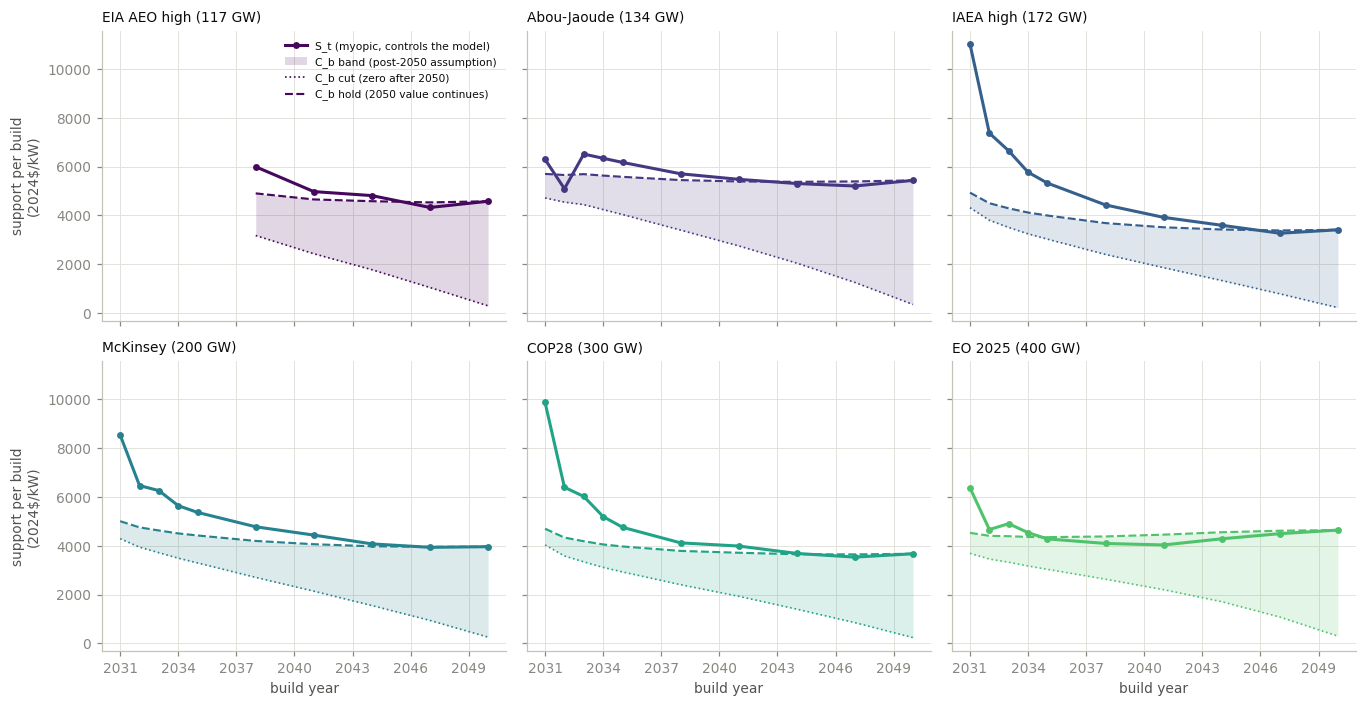

hold / myopic ratio, smr100: 0.23 .. 1.82 (builds through 2041: 0.23 .. 1.82)
hold / S at 2050 (identity check, expect near 1): 1.00 .. 1.00
post-2050 tail share of C_hold at 2050 builds: 0.94 .. 0.94


In [32]:
# ---- t11 + f14: myopia wedge with post-2050 extension band ----------------------------------------
EVAL_W = 30      # years; eval_period of both techs (financials_tech input)
# window discount rate = post-2026 system real rate; ordinary-annuity indexing
# (year b+j discounted by DRW^(j+1)) matches the ReEDS pvf_onm = 1/crf arithmetic.
DRW = float(np.mean(D_REAL[YEARS >= 2026]))
ann30 = sum(DRW ** -k for k in range(1, EVAL_W + 1))
pvf_run = float(PVF[REF].loc[2050])
assert abs(ann30 - pvf_run) / pvf_run < 0.01, (ann30, pvf_run)
print(f"window annuity at DRW={DRW - 1:.4%}: {ann30:.4f}; run pvf_onm(2050): {pvf_run:.4f}")

wed_rows = []
for c in CASES:
    d = DUALS[DUALS["case"] == c].set_index("t")["dual_2004_MWyr"].sort_index()
    d2050 = float(d.get(2050, 0.0))
    sub = t09[(t09["case"] == c) & (t09["status"] == "rate")].set_index("t")
    for b in sub.index:
        S = float(sub.loc[b, "S_t_2004_per_MW"])
        c_cut, c_hold = 0.0, 0.0
        for j in range(EVAL_W):
            y = b + j
            w = DRW ** -(j + 1)
            if y <= 2050:
                v = float(d.get(year_rep(y), 0.0))
                c_cut += v * w
                c_hold += v * w
            else:
                c_hold += d2050 * w
        wed_rows.append(dict(case=c, t=b, S_t_2004_per_MW=round(S),
                             C_cut_2004_per_MW=round(c_cut),
                             C_hold_2004_per_MW=round(c_hold),
                             cut_over_S=round(c_cut / S, 2),
                             hold_over_S=round(c_hold / S, 2),
                             tail_share_of_hold=round(1 - c_cut / c_hold, 2)
                                                if c_hold > 0 else 0.0))
t11 = pd.DataFrame(wed_rows)
t11.to_csv(EXPORTS / "t11_myopia_wedge.csv", index=False)

KW24 = TO2024 / 1e3      # 2004$/MW -> 2024$/kW
fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.5), sharex=True, sharey=True)
for k, s in enumerate(SCHEDULES):
    ax = axes.flat[k]
    cse = f"smr100_{s}_p50"
    w = t11[t11["case"] == cse].set_index("t").sort_index()
    ax.plot(w.index, w["S_t_2004_per_MW"] * KW24, color=SCHED_C[s], lw=2.0,
            marker="o", ms=3.5, label="S_t (myopic, controls the model)")
    ax.fill_between(w.index, w["C_cut_2004_per_MW"] * KW24,
                    w["C_hold_2004_per_MW"] * KW24, color=SCHED_C[s],
                    alpha=0.16, lw=0, label="C_b band (post-2050 assumption)")
    ax.plot(w.index, w["C_cut_2004_per_MW"] * KW24, color=SCHED_C[s], lw=1.1,
            ls=":", label="C_b cut (zero after 2050)")
    ax.plot(w.index, w["C_hold_2004_per_MW"] * KW24, color=SCHED_C[s], lw=1.4,
            ls="--", label="C_b hold (2050 value continues)")
    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    ax.set_title(SCHED_LABEL[s], fontsize=9)
    if k % 3 == 0:
        ax.set_ylabel("support per build\n(2024$/kW)")
    if k >= 3:
        ax.set_xlabel("build year")
axes.flat[0].legend(fontsize=7)
fig.tight_layout()
savefig(fig, "f14_myopia_wedge.png")
plt.show()

r = t11[t11["case"].str.startswith("smr100")]
early = r[r["t"] <= 2041]
print("hold / myopic ratio, smr100: "
      f"{r['hold_over_S'].min():.2f} .. {r['hold_over_S'].max():.2f} "
      f"(builds through 2041: {early['hold_over_S'].min():.2f} .. "
      f"{early['hold_over_S'].max():.2f})")
late = r[r["t"] == 2050]
print("hold / S at 2050 (identity check, expect near 1): "
      f"{late['hold_over_S'].min():.2f} .. {late['hold_over_S'].max():.2f}")
print("post-2050 tail share of C_hold at 2050 builds: "
      f"{late['tail_share_of_hold'].min():.2f} .. {late['tail_share_of_hold'].max():.2f}")


### t17 - the mandate priced per vintage (capacity-standard reading)

R_t (t08) bills the capacity-credit market by year, which truncates at 2050:
a 2047 vintage is credited three years of payments, a 2031 vintage twenty.
t17 removes the truncation by regrouping the same sum per vintage - each
vintage of program additions earns the clearing price over its 30-year
window - and bracketing the post-2050 price with the same cut/hold
conventions as C_b. The cut variant is the t08 sum in a different order, and
the cell asserts that identity per case. Inside the horizon the stream keeps
t08's solve-block discounting (which is what makes the identity exact); the
held tail discounts calendar years at the ledger rate. The fleet-rent column
is the pre-existing fleet's rent under the fleet-inclusive large100 standard
(within the horizon only); smr100 fleet rent is zero by construction.


In [33]:
# ---- t17: mandate cost restated per vintage (capacity-standard reading) --------------------------
per_rows = []
for c in CASES:
    d = DUALS[(DUALS["case"] == c) & (DUALS["t"] >= 2026)].set_index("t").sort_index()
    dual = d["dual_2004_MWyr"]
    prog = d["program_MW"]
    assert (prog.diff().dropna() >= -1e-6).all(), c    # additions basis is nondecreasing
    d2050 = float(dual.get(2050, 0.0))
    fleet = (d["mandate_MW"] - d["program_MW"]).clip(lower=0.0)
    pv_fleet = sum(float(dual[t]) * float(fleet[t]) * GAP[t] / DR ** (t - 2026)
                   for t in d.index)
    # per-vintage compliance stream: solve-block arithmetic inside the horizon
    # (reused from t08 - this keeps the cut identity exact), calendar years at
    # the held 2050 dual beyond it, through the vintage's 30-year window.
    stream_cut = {t: sum(float(dual[u]) * GAP[u] / DR ** (u - 2026)
                         for u in d.index if u >= t) for t in d.index}
    pv_cut = pv_hold = 0.0
    for k_i, t in enumerate(d.index):
        prev = d.index[k_i - 1] if k_i > 0 else None
        add = float(prog[t]) - (float(prog[prev]) if prev is not None else 0.0)
        if add <= 0:
            continue
        tail = sum(d2050 / DR ** (y - 2026) for y in range(2051, t + 30))
        pv_cut += add * stream_cut[t]
        pv_hold += add * (stream_cut[t] + tail)
    t08_pv = float(t08.set_index("case").loc[c, "PV_rental_transfer_2024B"])
    pv_cut24 = pv_cut * TO2024 / 1e9
    assert abs(pv_cut24 - t08_pv) <= max(0.06, 5e-3 * max(t08_pv, 1e-9)), (c, pv_cut24, t08_pv)
    per_rows.append(dict(case=c,
                         PV_newbuild_cut_2024B=round(pv_cut24, 1),
                         PV_newbuild_hold_2024B=round(pv_hold * TO2024 / 1e9, 1),
                         PV_fleet_rent_2024B=round(pv_fleet * TO2024 / 1e9, 1),
                         PV_mandate_cut_2024B=round((pv_cut + pv_fleet) * TO2024 / 1e9, 1),
                         PV_mandate_hold_2024B=round((pv_hold + pv_fleet) * TO2024 / 1e9, 1)))
t17 = pd.DataFrame(per_rows)
t17.to_csv(EXPORTS / "t17_mandate_perbuild.csv", index=False)
print("cut identity: the per-vintage restatement reproduces the t08 PV in every case (asserted).")
print(t17.to_string(index=False))


cut identity: the per-vintage restatement reproduces the t08 PV in every case (asserted).
              case  PV_newbuild_cut_2024B  PV_newbuild_hold_2024B  PV_fleet_rent_2024B  PV_mandate_cut_2024B  PV_mandate_hold_2024B
    smr100_eia_p05                    5.6                     6.0                  0.0                   5.6                    6.0
    smr100_eia_p50                   31.1                    59.6                  0.0                  31.1                   59.6
    smr100_eia_p95                   56.7                   110.0                  0.0                  56.7                  110.0
     smr100_aj_p05                    9.5                    21.9                  0.0                   9.5                   21.9
     smr100_aj_p50                   32.7                    98.9                  0.0                  32.7                   98.9
     smr100_aj_p95                   58.4                   171.3                  0.0                  58.4          

### Instrument comparison: the floor, the flat grant, and the ITC, net of tax

Symmetric scoring (2026-08-18): every instrument is valued through ReEDS's
own financing arithmetic. A dollar of commissioning-date cash - grant or
credit alike - pays down capital that would otherwise have to earn the
technology hurdle premium over the 30-year evaluation window, so its value
in dual currency is risk x eval_adj per after-tax dollar (eval_adj = 1
here). Scoring the credit through fin_mult but the grant as plain cash would
hand the credit a fictitious advantage; both get the leverage. (The old
asymmetric ledger's "avoided risk premium" discount was that artifact, and
it is gone.)

The floor: the minimum net government cost that delivers S_t to every build
is

floor = (1 - tau) x T / (risk x eval_adj), with T = sum of S_t x builds.

There is no cheaper targeted design: at the LP optimum every building region
has a zero reduced cost, so every builder's own gap equals S_t - verified
from the h5 `reduced_cost` output. The equalization is entry with endogenous
prices, and it means the floor needs only one public number per year (the
compliance price), not private cost information. (For a region that builds,
a zero reduced cost is LP optimality itself; the economic reading - every
builder's gap equals S_t - additionally assumes no other binding constraint
pays rent to those builds. Outside the model, private site rents and lumpy
builds would let some builders pocket part of a flat payment; that caveat
belongs to the discussion, not to this ledger.)

Tax character: T is pre-tax revenue requirement; a taxable grant returns
tau x T, so the unleveraged flat cash grant nets (1 - tau) x T = risk x
floor (tau = 0.257, the model's effective corporate rate, not the 21%
statutory rate).

The credit: face B (accrued to commissioning, see t10) is tax-free to the
developer; the government recoups tax on the halved depreciation basis,
N = B x (1 - tau x PV_dep / 2). Under symmetric scoring the identity

net ratio = N / floor = overshoot / (1 - penalty)

holds: the risk/eval leverage cancels between instrument and floor, and the
tax terms cancel exactly (k x claw = 1 - tau x PV_dep). The credit's excess
over the floor is the monetization haircut plus the uniform-rate overshoot -
two frictions, nothing else. The ratio against the flat grant stays as a
column for continuity; the gross ratio B / T stays as budget scoring only
(it understates the credit's relative cost because it ignores the tax the
grant returns).

Commitment companion: the same accumulation with C_b (t11) in place of S_t
prices the commitment bound - what vintage-b builds accept given a credible
declining schedule and foresight of the dual path (investor-side windows at
the post-2026 rate; ledger PV at DR). It is a bound, not a run: the myopic
model contains no such agent, and the dual path is itself myopic-equilibrium
output.

*Figure note (t13 figure): credit cost against the floor and the flat grant per case; gross budget scoring reverses the net-of-tax ranking.*

In [34]:
# ---- t13: floor, flat grant, and ITC — net-of-tax government cost (symmetric scoring) ----------
rows13 = []
cw_all = t11.set_index(["case", "t"])
for c in CASES:
    tech = META[c]["mandated_tech"]
    bl = CAPNEW[c]
    # LP optimality: no building (r, t) carries a reduced-cost row (zeros are suppressed)
    rc = load(c, "reduced_cost")
    rc = rc[(rc["i"] == tech) & (rc["*.1"] == "cap")]
    builders = set(zip(bl[bl > 0].index.get_level_values("r"),
                       bl[bl > 0].index.get_level_values("t")))
    overlap = builders & set(zip(rc["r"], rc["t"]))
    assert not overlap, (c, sorted(overlap)[:5])
    nbse, K, CCM = natfin(c)
    cc, fm = COSTCAP[c], FINMULT[c]
    # the technology hurdle premium inside fin_mult_noITC (same arithmetic as natfin)
    g46 = fin_tech(c)
    g46 = g46[g46["i"] == IN_NAME[tech]].set_index("t").reindex(YEARS).ffill().bfill()
    ev46 = float(g46["eval_period"].iloc[0])
    rk46 = pd.Series(1.0 + g46["finance_diff_real"].to_numpy(float)
                     * ((1 - (1 / D_REAL) ** ev46) / (D_REAL - 1.0)), index=YEARS)
    sub = t09[(t09["case"] == c) & (t09["status"] == "rate")].set_index("t")
    pv = dict(T=0.0, T_net=0.0, FLOOR=0.0, B=0.0, N=0.0, OV=0.0, RK=0.0, PRED=0.0,
              COM_cut=0.0, COM_hold=0.0)
    for t in sub.index:
        S = float(sub.loc[t, "S_t_2004_per_MW"])
        i_head = float(sub.loc[t, "i_model_headline"])
        ccm_t = float(CCM.loc[t])
        blt = bl.xs(t, level="t")
        blt = blt[blt > 0]
        fmb = fm.xs(t, level="t").reindex(blt.index)
        base = float(cc.loc[t]) * fmb / float(nbse.loc[t])     # OCC x regfac, 2004$/MW
        B_ann = i_head * ccm_t * float((base * blt).sum())     # face accrued to commissioning
        tau = float(TAX[yi(t)])
        k_t = float(K.loc[t])
        claw = 1.0 / (2.0 - k_t)                    # 1 - tau*PV_dep/2 (dep-basis clawback)
        rk_t = float(rk46.loc[t])
        bgap = t - TPREV[t]
        pv_w = sum(1.0 / DR ** (y - 2026) for y in range(t - bgap + 1, t + 1))
        pv["T"] += S * float(blt.sum()) * pv_w
        pv["T_net"] += S * float(blt.sum()) * (1.0 - tau) * pv_w
        # the floor: commissioning-date cash scored through the same financing
        # machinery as the credit (symmetric scoring, 2026-08-18)
        w_fl = S * float(blt.sum()) * (1.0 - tau) / rk_t * pv_w
        pv["FLOOR"] += w_fl
        pv["B"] += B_ann * pv_w
        pv["N"] += B_ann * claw * pv_w
        # net-ratio identity terms, floor-PV-weighted
        ov_t = float((fmb * blt).sum() / (fmb.min() * float(blt.sum())))
        pv["OV"] += ov_t * w_fl
        pv["RK"] += rk_t * w_fl
        pv["PRED"] += ov_t / (1.0 - PEN) * w_fl
        # commitment bound: the same accumulation with C_b in place of S_t
        pv["COM_cut"] += (float(cw_all.loc[(c, t), "C_cut_2004_per_MW"])
                          * float(blt.sum()) * (1.0 - tau) / rk_t * pv_w)
        pv["COM_hold"] += (float(cw_all.loc[(c, t), "C_hold_2004_per_MW"])
                           * float(blt.sum()) * (1.0 - tau) / rk_t * pv_w)
    v = {k_: pv[k_] * TO2024 / 1e9
         for k_ in ("T", "T_net", "FLOOR", "B", "N", "COM_cut", "COM_hold")}
    ov_w = pv["OV"] / pv["FLOOR"]
    rk_w = pv["RK"] / pv["FLOOR"]
    pred = pv["PRED"] / pv["FLOOR"]
    # identity: net ratio vs floor = overshoot / (1 - penalty); the risk/eval
    # leverage cancels between instrument and floor, and the tax terms cancel
    # exactly (k x claw = 1 - tau x PV_dep). tolerance 5e-3: B uses the
    # 3-dp-rounded i_model_headline from t09 (exact when unrounded).
    assert abs(pred - v["N"] / v["FLOOR"]) < 5e-3, (c, pred, v["N"] / v["FLOOR"])
    assert abs(v["B"] - float(cmp_tbl.loc[c, "PV_ITC_outlay_2024B"])) <= max(0.06, 5e-3 * v["B"])
    rows13.append(dict(case=c,
                       PV_flat_grant_2024B=round(v["T"], 1),
                       PV_grant_net_2024B=round(v["T_net"], 1),
                       PV_floor_2024B=round(v["FLOOR"], 1),
                       PV_ITC_outlay_2024B=round(v["B"], 1),
                       PV_ITC_net_2024B=round(v["N"], 1),
                       PV_commit_cut_2024B=round(v["COM_cut"], 1),
                       PV_commit_hold_2024B=round(v["COM_hold"], 1),
                       net_ratio_vs_floor=round(v["N"] / v["FLOOR"], 2),
                       net_ratio_vs_grant=round(v["N"] / v["T_net"], 2),
                       gross_scoring_ratio=round(v["B"] / v["T"], 2),
                       capex_overshoot=round(ov_w, 4),
                       risk_premium_factor=round(rk_w, 4),
                       pred_net_ratio=round(pred, 4)))
t13 = pd.DataFrame(rows13)
t13.to_csv(EXPORTS / "t13_flat_grant.csv", index=False)
print("reduced-cost check: no building (r, t) has a nonzero reduced cost, in any "
      "case (LP optimality at basic builds; see the markdown note above).")
print(t13.to_string(index=False))
for fam in ("smr100", "large100"):
    f = t13[t13["case"].str.startswith(fam)]
    print(f"\n{fam}  net vs floor: "
          f"{f['net_ratio_vs_floor'].min():.2f} .. {f['net_ratio_vs_floor'].max():.2f}"
          f";  net vs flat grant: {f['net_ratio_vs_grant'].min():.2f} .. "
          f"{f['net_ratio_vs_grant'].max():.2f}"
          f";  gross scoring B/T: {f['gross_scoring_ratio'].min():.2f} .. "
          f"{f['gross_scoring_ratio'].max():.2f}")


reduced-cost check: no building (r, t) has a nonzero reduced cost, in any case (LP optimality at basic builds; see the markdown note above).
              case  PV_flat_grant_2024B  PV_grant_net_2024B  PV_floor_2024B  PV_ITC_outlay_2024B  PV_ITC_net_2024B  PV_commit_cut_2024B  PV_commit_hold_2024B  net_ratio_vs_floor  net_ratio_vs_grant  gross_scoring_ratio  capex_overshoot  risk_premium_factor  pred_net_ratio
    smr100_eia_p05                 20.2                15.0            14.4                 19.5              18.0                  3.7                   4.0                1.25                1.20                 0.96           1.1275               1.0426          1.2528
    smr100_eia_p50                 61.2                45.4            43.6                 57.8              53.5                 20.4                  38.0                1.23                1.18                 0.95           1.1055               1.0426          1.2283
    smr100_eia_p95                107.6 

saved -> figures\t13_instrument_comparison.png


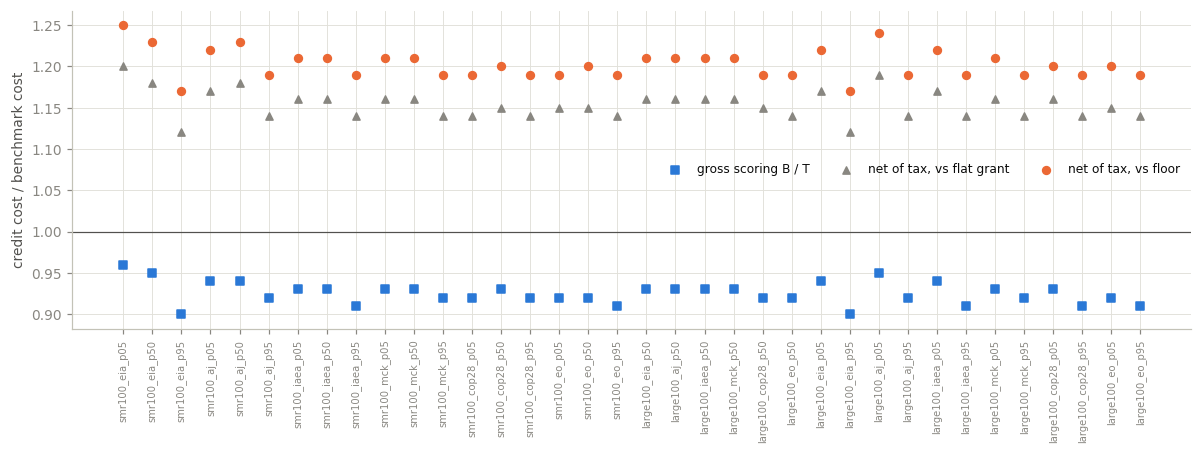

In [35]:
# ---- t13 figure: instrument comparison, regenerated on the 37-case basis --------------
fcmp = t13[~t13["case"].str.endswith("_eq")].set_index("case")
fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(fcmp))
ax.axhline(1.0, lw=0.8, color=MUTED, zorder=1)
ax.scatter(x, fcmp["gross_scoring_ratio"], marker="s", s=22, color=COL["large"],
           label="gross scoring B / T")
ax.scatter(x, fcmp["net_ratio_vs_grant"], marker="^", s=22, color=FAINT,
           label="net of tax, vs flat grant")
ax.scatter(x, fcmp["net_ratio_vs_floor"], marker="o", s=26, color=COL["smr"],
           label="net of tax, vs floor")
ax.set_xticks(x)
ax.set_xticklabels(fcmp.index, rotation=90, fontsize=6.5)
ax.set_ylabel("credit cost / benchmark cost")
ax.legend(fontsize=8, ncol=3)
fig.tight_layout()
savefig(fig, "t13_instrument_comparison.png")
plt.show()


### Rate resolution: federal, state, and zone ITC

One percentage rate (model convention) per geography per year. Each
geography uses the smallest rate that delivers S_t to every zone that builds
inside it (by the equalization above, every builder needs the full S_t). The
federal rung is then exactly the t10 headline outlay B_t; the cell asserts
this identity. Finer resolution saves money only through the rate
conversion: a percentage rate maxed for the cheapest capex base overdelivers
through every larger base. The state map comes from
`inputs/zones/z90/hierarchy.csv`. A credit denominated in dollars per MW
removes the overshoot in one step; its cost is the menu's $/MW rung (t18).

In [36]:
# ---- t14: ITC outlay by rate resolution (federal / state / zone) -------------------------------
R2ST = pd.read_csv(REPO / "inputs" / "zones" / "z90" / "hierarchy.csv").set_index("r")["st"]
rows14 = []
for c in CASES:
    nbse, K, CCM = natfin(c)
    cc, fm, bl = COSTCAP[c], FINMULT[c], CAPNEW[c]
    sub = t09[(t09["case"] == c) & (t09["status"] == "rate")].set_index("t")
    pv = dict(fed=0.0, state=0.0, zone=0.0)
    for t in sub.index:
        S = float(sub.loc[t, "S_t_2004_per_MW"])
        blt = bl.xs(t, level="t")
        blt = blt[blt > 0]
        fmb = fm.xs(t, level="t").reindex(blt.index)
        FC = float(cc.loc[t]) * fmb
        i_need = (S * float(K.loc[t])
                  / ((1.0 - PEN) * FC))     # model-convention rate that delivers S_t in r
        cost = (FC / float(nbse.loc[t]) * blt
                * float(CCM.loc[t]))    # capex base x builds, accrued to commissioning
        st = R2ST.reindex(blt.index)
        assert not st.isna().any(), (c, t, list(blt.index[st.isna()]))
        bgap = t - TPREV[t]
        pv_w = sum(1.0 / DR ** (y - 2026) for y in range(t - bgap + 1, t + 1))
        pv["fed"] += float(i_need.max()) * float(cost.sum()) * pv_w
        pv["state"] += float((i_need.groupby(st).transform("max") * cost).sum()) * pv_w
        pv["zone"] += float((i_need * cost).sum()) * pv_w
    fed, stt, zn = (pv[k_] * TO2024 / 1e9 for k_ in ("fed", "state", "zone"))
    B_head = float(cmp_tbl.loc[c, "PV_ITC_outlay_2024B"])
    assert abs(fed - B_head) <= max(0.06, 5e-3 * B_head), (c, fed, B_head)
    rows14.append(dict(case=c, PV_fed_2024B=round(fed, 1), PV_state_2024B=round(stt, 1),
                       PV_zone_2024B=round(zn, 1),
                       state_saving=round(1.0 - stt / fed, 3),
                       zone_saving=round(1.0 - zn / fed, 3)))
t14 = pd.DataFrame(rows14)
t14.to_csv(EXPORTS / "t14_itc_resolution.csv", index=False)
print("federal rung reproduces the t10 headline outlay in every case (asserted).")
print(t14.to_string(index=False))
for fam in ("smr100", "large100"):
    f = t14[t14["case"].str.startswith(fam)]
    print(f"\n{fam}  state saving: {100 * f['state_saving'].min():.0f} .. "
          f"{100 * f['state_saving'].max():.0f} %;  zone adds at most "
          f"{100 * (f['zone_saving'] - f['state_saving']).max():.1f} points")

federal rung reproduces the t10 headline outlay in every case (asserted).
              case  PV_fed_2024B  PV_state_2024B  PV_zone_2024B  state_saving  zone_saving
    smr100_eia_p05          19.5            17.3           17.3         0.111        0.113
    smr100_eia_p50          57.8            52.3           52.3         0.095        0.095
    smr100_eia_p95          97.2            92.1           92.1         0.052        0.052
     smr100_aj_p05          25.4            23.1           23.1         0.090        0.092
     smr100_aj_p50          84.4            76.6           76.5         0.092        0.094
     smr100_aj_p95         145.4           136.1          135.6         0.064        0.067
   smr100_iaea_p05          53.9            49.7           49.6         0.077        0.081
   smr100_iaea_p50         181.4           167.5          167.1         0.077        0.079
   smr100_iaea_p95         343.9           322.5          322.3         0.062        0.063
    smr100_mck_p

### t18 - the subsidy instrument menu

One exhibit, the centerpiece: each instrument's net PV cost as a multiple of
the floor, per case. The menu is indexed by institutional capability - each
step down demands more of the state, not more information about builders:

- **floor** (1.00): flat $-per-MW support at commissioning, elective pay -
  needs a statute that pays dollars per MW with no monetization haircut.
- **$/MW with the 10% haircut**: x 1/(1-0.1) = 1.11.
- **unleveraged flat cash grant** (taxable, no financing leverage): x risk =
  1.04 - shown to make the scoring convention visible.
- **uniform percentage ITC**: x overshoot/(1-0.1) - adds the uniform-rate
  overshoot, because a percentage of heterogeneous capex bases pays the
  cheapest-base rate to every costlier base (t14 prices partial repairs).
- **capacity-standard mandate** (t17, cut-hold band, net of tax): pays every
  standing vintage the clearing price - including the pre-existing fleet in
  the large100 cases - so it is the expensive end wherever a fleet collects
  rent.
- **commitment bound** (below 1 where duals decline): pays vintage b its
  foresight value C_b - needs a credible multi-decade schedule and
  foresighted investors, and the dual path is myopic-equilibrium output, so
  it is a bound, not a run.

One reading rule: the smr100 mandate rung sits *below* the floor. That is
coherent - compliance is compelled, not induced, so the capacity market pays
only the realized declining price path (the commitment bound's stream, plus
fleet rent where a fleet exists), not each vintage's myopic requirement S_t.
The floor is the minimum among *voluntary* subsidy instruments facing myopic
investors; instruments that rely on coercion (the mandate) or on credible
commitment (the C_b schedule) can undercut it, and the gap between them and
the floor is the price of voluntariness under myopia.

Payment timing is not a rung: at these rates (ccmult accrual 8.0% nominal
against a 7.99% ledger WACC) early payment is PV-neutral; paying earlier
trades a government-borrowing-rate wedge against construction-completion
risk (the loan-guarantee limit), both outside this ledger. A production
credit (PTC) is also not a rung: by the same conservation-of-money logic its
net cost lands with the grant's, up to payment-window discounting.


              case  PV_floor_2024B  dpmw_electivepay  dpmw_haircut  cash_grant  uniform_itc  mandate_cut  mandate_hold  commitment_cut  commitment_hold
    smr100_eia_p05            14.4               1.0         1.111        1.04         1.25         0.29          0.31            0.26             0.28
    smr100_eia_p50            43.6               1.0         1.111        1.04         1.23         0.53          1.02            0.47             0.87
    smr100_eia_p95            76.7               1.0         1.111        1.04         1.17         0.55          1.07            0.49             0.92
     smr100_aj_p05            19.2               1.0         1.111        1.04         1.22         0.37          0.85            0.32             0.73
     smr100_aj_p50            63.7               1.0         1.111        1.04         1.23         0.38          1.15            0.34             0.99
     smr100_aj_p95           112.9               1.0         1.111        1.04         1

saved -> figures\f16_instrument_menu.png


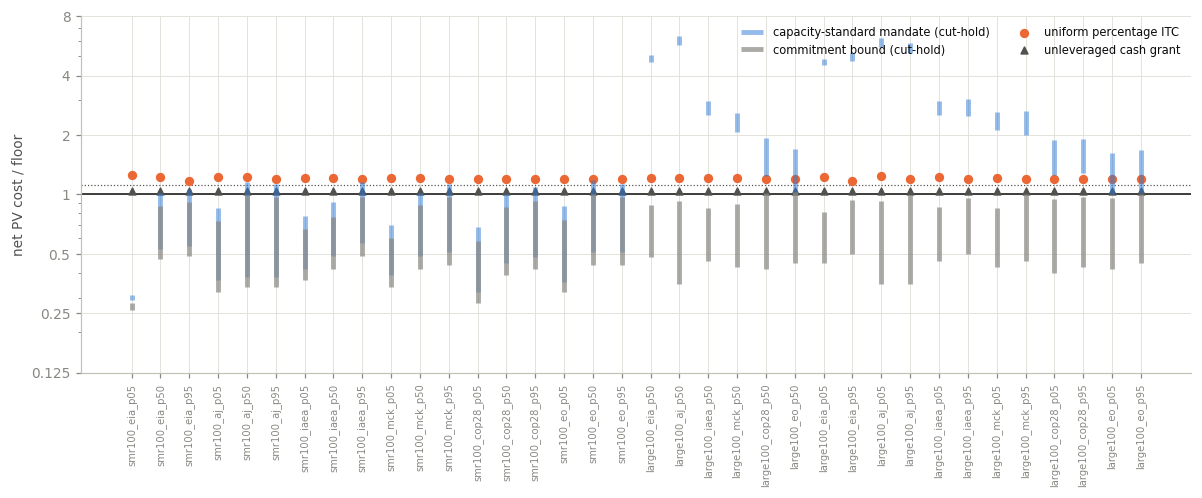

smr100: uniform ITC 1.17..1.25 x floor;  mandate hold 0.31..1.18;  commitment hold 0.28..1.00
large100: uniform ITC 1.17..1.24 x floor;  mandate hold 1.63..6.33;  commitment hold 0.81..1.03


In [37]:
# ---- t18 + f16: the subsidy instrument menu ------------------------------------------------------
TAXA = np.asarray(TAX, dtype=float)[YEARS >= 2026]
assert float(TAXA.max() - TAXA.min()) < 1e-9   # flat from 2018 on; a scalar is exact
TAUC = float(TAXA.flat[0])
men = t13.set_index("case").join(t17.set_index("case"))
rows18 = []
for c, r in men.iterrows():
    fl = float(r["PV_floor_2024B"])
    if fl <= 0:
        continue
    rows18.append(dict(
        case=c,
        PV_floor_2024B=round(fl, 1),
        dpmw_electivepay=1.0,
        dpmw_haircut=round(1.0 / (1.0 - PEN), 3),
        cash_grant=round(float(r["PV_grant_net_2024B"]) / fl, 2),
        uniform_itc=round(float(r["PV_ITC_net_2024B"]) / fl, 2),
        mandate_cut=round((1.0 - TAUC) * float(r["PV_mandate_cut_2024B"]) / fl, 2),
        mandate_hold=round((1.0 - TAUC) * float(r["PV_mandate_hold_2024B"]) / fl, 2),
        commitment_cut=round(float(r["PV_commit_cut_2024B"]) / fl, 2),
        commitment_hold=round(float(r["PV_commit_hold_2024B"]) / fl, 2)))
t18 = pd.DataFrame(rows18)
t18.to_csv(EXPORTS / "t18_instrument_menu.csv", index=False)
print(t18.to_string(index=False))

f18 = t18[~t18["case"].str.endswith("_eq")].set_index("case")
fig, ax = plt.subplots(figsize=(11, 4.6))
x = np.arange(len(f18))
ax.axhline(1.0, lw=1.0, color=INK, zorder=1)
ax.axhline(1.0 / (1.0 - PEN), lw=0.8, color=MUTED, ls=":", zorder=1)
ax.vlines(x, f18["mandate_cut"], f18["mandate_hold"], color=COL["large"], lw=3.2,
          alpha=0.5, label="capacity-standard mandate (cut-hold)")
ax.vlines(x, f18["commitment_cut"], f18["commitment_hold"], color=FAINT, lw=3.2,
          alpha=0.7, label="commitment bound (cut-hold)")
ax.scatter(x, f18["uniform_itc"], marker="o", s=26, color=COL["smr"],
           label="uniform percentage ITC")
ax.scatter(x, f18["cash_grant"], marker="^", s=20, color=MUTED,
           label="unleveraged cash grant")
ax.set_yscale("log")
ax.set_yticks([0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0])
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%g"))
ax.set_xticks(x)
ax.set_xticklabels(f18.index, rotation=90, fontsize=6.5)
ax.set_ylabel("net PV cost / floor")
ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout()
savefig(fig, "f16_instrument_menu.png")
plt.show()
for fam in ("smr100", "large100"):
    f = t18[t18["case"].str.startswith(fam) & ~t18["case"].str.endswith("_eq")]
    print(f"{fam}: uniform ITC {f['uniform_itc'].min():.2f}..{f['uniform_itc'].max():.2f}"
          f" x floor;  mandate hold {f['mandate_hold'].min():.2f}.."
          f"{f['mandate_hold'].max():.2f};  commitment hold "
          f"{f['commitment_hold'].min():.2f}..{f['commitment_hold'].max():.2f}")


### t19 - the commitment ITC (companion schedule)

Push C_b through the same inversion that produces i_model from S_t and you
get the rate schedule a foresighted investor accepts under a credible
declining path: flatter across vintages, and immune to rate-lock gaming
(t16 prices the windfall an S_t-based schedule hands a 6-year BOC lock; a
C_b-based schedule pays each vintage its indifference value, so there is no
spread to lock). Symmetric caveat: if investors are myopic - as ReEDS's
are - the commitment schedule underpays and deployment fails; the pair
(i_model, i_commit) brackets the behavioral assumption. Cut/hold brackets
the post-2050 duals as everywhere.


In [38]:
# ---- t19: the commitment ITC rate schedule -------------------------------------------------------
rows19 = []
cw19 = t11.set_index(["case", "t"])
for c in CASES:
    nbse, K, CCM = natfin(c)
    cc, fm, bl = COSTCAP[c], FINMULT[c], CAPNEW[c]
    sub = t09[(t09["case"] == c) & (t09["status"] == "rate")].set_index("t")
    for t in sub.index:
        blt = bl.xs(t, level="t")
        blt = blt[blt > 0]
        fmb = fm.xs(t, level="t").reindex(blt.index)
        den = (1.0 - PEN) * float(cc.loc[t]) * float(fmb.min())
        i_m = float(sub.loc[t, "i_model_headline"])
        # same inversion as t09's headline (S x K / den); sanity vs the table
        assert abs(float(sub.loc[t, "S_t_2004_per_MW"]) * float(K.loc[t]) / den
                   - i_m) < 5e-3, (c, t)
        rows19.append(dict(
            case=c, t=t,
            i_commit_cut=round(float(cw19.loc[(c, t), "C_cut_2004_per_MW"])
                               * float(K.loc[t]) / den, 3),
            i_commit_hold=round(float(cw19.loc[(c, t), "C_hold_2004_per_MW"])
                                * float(K.loc[t]) / den, 3),
            i_model_headline=i_m))
t19 = pd.DataFrame(rows19)
t19["hold_over_model"] = (t19["i_commit_hold"] / t19["i_model_headline"]).round(2)
t19.to_csv(EXPORTS / "t19_commitment_itc.csv", index=False)
f19 = t19[t19["case"].str.startswith("smr100") & t19["case"].str.endswith("_p50")]
dm = f19.groupby("case")["i_model_headline"].apply(lambda s: s.diff().abs().mean())
dc = f19.groupby("case")["i_commit_hold"].apply(lambda s: s.diff().abs().mean())
print(f"smr100 p50 mean |year-over-year rate step|: myopic {dm.mean():.3f}, "
      f"commitment-hold {dc.mean():.3f} (flatter)")
print(f"hold_over_model, smr100: {f19['hold_over_model'].min():.2f} .. "
      f"{f19['hold_over_model'].max():.2f} at p50")


smr100 p50 mean |year-over-year rate step|: myopic 0.053, commitment-hold 0.037 (flatter)
hold_over_model, smr100: 0.45 .. 1.11 at p50


## S9 — Equality-flip note

`smr100_eia_p50_eq` runs the same world as `smr100_eia_p50` with the mandate as
a floor plus a ceiling (`GSw_NuclearCapMandate=2`). The QA notebook compared
the two runs (phase D). Summary of the evidence:

In [39]:
eqf = pd.read_csv(CHECKS_EXPORTS / "eq_flip_comparison.csv")
print(eqf.to_string(index=False))
o1, o2 = OBJ["smr100_eia_p50"], OBJ["smr100_eia_p50_eq"]
print(f"\nobjective: floor {o1:.6e}, equality {o2:.6e}, rel diff {abs(o1-o2)/o1:.1e}")
has_ub = "nuclear_cap_price_ub" in h5_keys("smr100_eia_p50_eq")
print(f"ceiling dual key present in the eq h5: {has_ub} "
      "(absent = all-zero = the ceiling never binds)")
d1 = DUALS[DUALS['case'] == 'smr100_eia_p50'].set_index('t')['dual_2004_MWyr']
d2 = DUALS[DUALS['case'] == 'smr100_eia_p50_eq'].set_index('t')['dual_2004_MWyr']
print(f"floor duals, max rel diff: "
      f"{float(((d1 - d2).abs() / d1.clip(lower=1)).max()):.1e}")


dataset  max_abs_diff  max_rel_diff              worst_at
    cap      3.632812      0.000438  ('wind-ons_9', 2050)
gen_ann 600696.000000      0.027753 ('wind-ofs_10', 2041)

objective: floor 1.631947e+12, equality 1.631947e+12, rel diff 0.0e+00
ceiling dual key present in the eq h5: False (absent = all-zero = the ceiling never binds)
floor duals, max rel diff: 2.2e-05


The objective is identical. The floor duals match. The ceiling dual is
all-zero, so the writer dropped its key. The remaining solution differences
(`cap` max relative difference about 4e-4, `gen_ann` about 3e-2) sit at the
scale of a degenerate-LP reshuffle in non-nuclear technologies. Conclusion:
the constraint form causes no change in behavior. The floor lock (issue 6)
loses nothing. The fans in this notebook exclude the equality copy.

## S10 — Caveats and limitations

1. **National aggregates only.** Identical national builds diverge in siting
   across cost worlds, and the reshuffle propagates to transmission and
   dispatch (P7). Regional or transmission readouts across cases are
   siting-degenerate. This notebook does not show them.
2. **No no-mandate baseline.** No number here is a mandate-against-
   counterfactual cost.
3. **Cross-schedule comparisons conflate the mandate and the drawn cost
   world.** Each schedule x percentile is its own joint draw.
4. **Sequential, myopic solve.** The duals are per-solve marginals without
   foresight. A forward-looking planner can price the same floor differently.
5. **NPV end effects.** Lump capex plus a 2050 window penalizes late builds in
   the ambitious schedules.
6. **ITC translation status.** The rates in S8 follow
   `ITC calculation procedure.md` (sequential logic: S_t = raw dual, no
   discounting across years; fin_mult inversion). Convention revised
   2026-08-18 (supersedes the 2026-08-14 statutory lock): the headline is
   the model-convention rate i_model; a placed-in-service credit on an
   overnight-cost-only basis is i_model x ccmult (exported as the i_pis_*
   columns), and under Section 263A(f) a real owner's statutory rate lies
   between the two. Two legal inputs can still move the rate level: the
   monetization haircut (0.1 here) and the depreciation recovery class
   (15-year MACRS here). The companion
   value C_b depends on the dual path
   after 2050, which the model does not see. The notebook brackets it with two
   conventions (zero after 2050, and the 2050 value held through the window);
   read only conclusions that hold across the band. In the p95 worlds the
   dual is still rising at 2050, so there the hold variant is a lower bound,
   not an upper bracket.
7. **Adverse findings recap.** `smr100_eia_p05` overbuilds its floor by up to
   3%. Every large100 case (all 18) has two clearly slack years, and the
   `large100_eia_*` cases price their floor in only 6 of 12 mandated years at
   every percentile. In the p95 worlds — both families — the dual does not
   decay by 2050: the bridge does not come down inside the horizon in the
   expensive draws (large100 p95 end/peak 0.84–0.95). The required
   model-convention ITC exceeds 100% in 5 of 329 unique rate case-years
   (334 rows counting the equality duplicate, which adds none) — the late
   p95 years of the eo schedule in both families plus cop28's 2050; the
   placed-in-service OCC-only conversion (i_pis) exceeds 100% in 82,
   concentrated in the large100 p95 worlds. In the most expensive worlds an
   ITC alone cannot deliver the late years.

The pilot runs (`smr100_eia_{lo,mid,hi}`) are not in this analysis, and their
dual levels are never quotable.

In [40]:
# ---- output manifest -------------------------------------------------------------------------------
print("files that this notebook wrote:\n")
for d in (EXPORTS, FIGURES):
    for p in sorted(d.iterdir()):
        print(f"  {p.relative_to(HERE)}  ({p.stat().st_size / 1e3:.0f} kB)")


files that this notebook wrote:

  exports\t01_case_inventory.csv  (4 kB)
  exports\t02_slack_years.csv  (2 kB)
  exports\t03_dual_summary.csv  (2 kB)
  exports\t04_bridge_metrics.csv  (1 kB)
  exports\t05_systemcost_by_case.csv  (187 kB)
  exports\t06_cost_deltas.csv  (2 kB)
  exports\t07_system_npv.csv  (1 kB)
  exports\t08_rental_transfer.csv  (1 kB)
  exports\t09_required_itc.csv  (37 kB)
  exports\t10_itc_outlay.csv  (12 kB)
  exports\t11_myopia_wedge.csv  (20 kB)
  exports\t12_fiscal_comparison.csv  (1 kB)
  exports\t13_flat_grant.csv  (4 kB)
  exports\t14_itc_resolution.csv  (2 kB)
  exports\t15_large_ratio.csv  (1 kB)
  exports\t16_boc_windfall.csv  (15 kB)
  exports\t17_mandate_perbuild.csv  (2 kB)
  exports\t18_instrument_menu.csv  (2 kB)
  exports\t19_commitment_itc.csv  (15 kB)
  figures\f01_mandate_trajectories.png  (242 kB)
  figures\f02_binding_heatmap.png  (365 kB)
  figures\f03_mandate_vs_cap.png  (564 kB)
  figures\f04_dual_fans.png  (620 kB)
  figures\f05_dual_all_p5